# Predicting Property Prices in Ames
## Capstone Project 1 — End-to-End Machine Learning

**Dataset:** 1,460 residential sales in Ames, Iowa  
**Target:** `PropPrice` — the property's sale price in dollars  
**Goal:** Build a model that predicts sale price from house characteristics, with an expected **R² of 75–85%** (higher is better)

---

### The story this notebook tells

A buyer walking through Ames does not see 80 columns. They see a neighborhood, a kitchen, a garage, and a feeling that "this house is worth more than the one next door." A seller sees the same house through a different lens: remodel year, lot size, and whether the basement is finished.

This project translates that human judgment into a machine-learning pipeline. We will:

1. Load and **understand** the real estate data
2. **Clean** it without throwing away useful columns
3. Use **EDA** to find what actually moves price
4. Engineer features the way an appraiser would
5. Encode **ordinal** and **nominal** fields separately
6. Impute missing values, **scale**, and apply **PCA**
7. Train several algorithms and pick a winner with MAE, RMSE, and R²

> **Constraint from the brief:** do **not** drop columns except `PropertyID`. High-missing fields such as `PoolQC` and `Alley` are not junk — "no pool" is information.

## 1. Introduction to the Project

The real estate market is noisy. Two homes on the same street can differ by six figures because of finish quality, a finished basement, or a remodel completed last year. Predicting an accurate price matters for:

- **Buyers** who do not want to overpay
- **Sellers** who do not want to leave money on the table
- **Agents and lenders** who need a defensible estimate

This capstone uses a renamed Ames Housing dataset (Dean De Cock). Each row is one closed sale. The target `PropPrice` is the actual transaction price.

The data mixes:

| Kind of signal | Examples | Why it matters |
|---|---|---|
| Size | `GrLivArea`, `PropertySize`, `BsmntSqFtage` | Bigger homes usually sell for more |
| Quality | `OverallQual`, `KitchenQual`, `ExterQual` | Finish quality is one of the strongest price drivers |
| Age / updates | `YearBuilt`, `YearRemodAdd` | Newer and recently remodeled homes command a premium |
| Location | `Neighborhood`, `Condition1` | Ames neighborhoods are not interchangeable |
| Amenities | garage, fireplace, porch, pool | Extra living space outdoors and parking add value |

## 2. Objectives of the Project

1. Collect and clean real-estate data for a specific location (Ames)
2. Handle **ordinal** and **nominal** columns separately, using domain metadata
3. Use `fillna()`, **scaling**, and **PCA** to handle missing data and improve the model
4. Perform **EDA** to identify the variables that actually influence price
5. Apply the **correct encoding** for ordinal vs nominal features
6. Develop a machine-learning model that predicts `PropPrice`
7. Evaluate performance and **compare algorithms**
8. Present findings as a clear data story

**Success bar:** R² between **75% and 85%**; above 85% is excellent.

## 3. Flow Chart of Operations

```mermaid
flowchart TD
    A[Load Property_data.csv] --> B[Understand shape, types, missingness]
    B --> C[Drop PropertyID only]
    C --> D[Exploratory Data Analysis]
    D --> E[Feature Engineering]
    E --> F[Train / Test Split]
    F --> G[Impute missing values from train]
    G --> H[Ordinal mapping + Nominal one-hot]
    H --> I[Feature scaling]
    I --> J[PCA]
    J --> K[Train multiple models]
    K --> L[Evaluate MAE, RMSE, R2]
    L --> M[Interpret insights and save best model]
    M --> N[Conclusion]
```

Leakage rule: medians, one-hot categories, scalers, and PCA are **fit on the training set only**, then applied to the test set.

## Step 4. Environment Setup

Import the libraries used for cleaning, visualization, encoding, scaling, PCA, and modeling.

In [429]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display
import joblib

# Step 5: load the dataset

In [430]:
df = pd.read_csv("Propertydata.csv")
df.head(15)

,PropertyID,PropertyClass,PropertyZone,PropertyFrontage,PropertySize,Street,Alley,PropertyShape,Elevation,Amenities,Orientation,Grade,Neighborhood,Condition1,Condition2,BldgType,PropertyStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Roof1Material,Roof2Material,ExteriorCladdingType,ExteriorCladdingArea,ExterQual,ExterCond,PropertyFooting,BsmntFinish,BsmntMaintenance,BsmntVisibility,BsmntFinRat1,BsmntFinSty1,BsmntFinQual1,BsmtFinSF2,BsmtUnfSF,BsmntSqFtage,Heating,HeatingEfficiency,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,Bath1,Bath2,BedroomUpLev,KitchenUpLev,KitchenQual,CntRmsUpLev,Functional,CntFireplaces,QualFireplace,BasementType,BasementYrBlt,BasementFinish,BasementCars,BasementSqFootage,BasementQual,BasementCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,BoundaryFeatures,AddFeatures,AddVal,SaleMon,SaleYr,SaleType,SaleCondn,PropPrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1.5Fin,5,5,1993,1995,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,Wood,Gd,TA,No,GLQ,732,Unf,0,64,796,GasA,Ex,Y,SBrkr,796,566,0,1362,1,0,1,1,1,1,TA,5,Typ,0,NaN,Attchd,1993.0,Unf,2,480,TA,TA,Y,40,30,0,320,0,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,1Fam,1Story,8,5,2004,2005,Gable,CompShg,VinylSd,VinylSd,Stone,186.0,Gd,TA,PConc,Ex,TA,Av,GLQ,1369,Unf,0,317,1686,GasA,Ex,Y,SBrkr,1694,0,0,1694,1,0,2,0,3,1,Gd,7,Typ,1,Gd,Attchd,2004.0,RFn,2,636,TA,TA,Y,255,57,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NWAmes,PosN,Norm,1Fam,2Story,7,6,1973,1973,Gable,CompShg,HdBoard,HdBoard,Stone,240.0,TA,TA,CBlock,Gd,TA,Mn,ALQ,859,BLQ,32,216,1107,GasA,Ex,Y,SBrkr,1107,983,0,2090,1,0,2,1,3,1,TA,7,Typ,2,TA,Attchd,1973.0,RFn,2,484,TA,TA,Y,235,204,228,0,0,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Artery,Norm,1Fam,1.5Fin,7,5,1931,1950,Gable,CompShg,BrkFace,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,TA,No,Unf,0,Unf,0,952,952,GasA,Gd,Y,FuseF,1022,752,0,1774,0,0,2,0,2,2,TA,8,Min1,2,TA,Detchd,1931.0,Unf,2,468,Fa,TA,Y,90,0,205,0,0,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,BrkSide,Artery,Artery,2fmCon,1.5

# Step 6: Understand the Dataset

In [431]:
df.shape

(1460, 81)

In [432]:
# Display all column names
df.columns.tolist()

['PropertyID',
 'PropertyClass',
 'PropertyZone',
 'PropertyFrontage',
 'PropertySize',
 'Street',
 'Alley',
 'PropertyShape',
 'Elevation',
 'Amenities',
 'Orientation',
 'Grade',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'PropertyStyle',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'RoofStyle',
 'RoofMatl',
 'Roof1Material',
 'Roof2Material',
 'ExteriorCladdingType',
 'ExteriorCladdingArea',
 'ExterQual',
 'ExterCond',
 'PropertyFooting',
 'BsmntFinish',
 'BsmntMaintenance',
 'BsmntVisibility',
 'BsmntFinRat1',
 'BsmntFinSty1',
 'BsmntFinQual1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'BsmntSqFtage',
 'Heating',
 'HeatingEfficiency',
 'CentralAir',
 'Electrical',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'Bath1',
 'Bath2',
 'BedroomUpLev',
 'KitchenUpLev',
 'KitchenQual',
 'CntRmsUpLev',
 'Functional',
 'CntFireplaces',
 'QualFireplace',
 'BasementType',
 'BasementYrBlt',
 'BasementFinish',
 'BasementCars',

In [433]:
# Statistical summary including categorical columns
df.describe(include="all")

,PropertyID,PropertyClass,PropertyZone,PropertyFrontage,PropertySize,Street,Alley,PropertyShape,Elevation,Amenities,Orientation,Grade,Neighborhood,Condition1,Condition2,BldgType,PropertyStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Roof1Material,Roof2Material,ExteriorCladdingType,ExteriorCladdingArea,ExterQual,ExterCond,PropertyFooting,BsmntFinish,BsmntMaintenance,BsmntVisibility,BsmntFinRat1,BsmntFinSty1,BsmntFinQual1,BsmtFinSF2,BsmtUnfSF,BsmntSqFtage,Heating,HeatingEfficiency,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,Bath1,Bath2,BedroomUpLev,KitchenUpLev,KitchenQual,CntRmsUpLev,Functional,CntFireplaces,QualFireplace,BasementType,BasementYrBlt,BasementFinish,BasementCars,BasementSqFootage,BasementQual,BasementCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,BoundaryFeatures,AddFeatures,AddVal,SaleMon,SaleYr,SaleType,SaleCondn,PropPrice
count,1460.000000,1460.000000,1460,1201.000000,1460.000000,1460,91,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460.000000,1460.000000,1460.000000,1460.000000,1460,1460,1460,1460,588,1452.000000,1460,1460,1460,1423,1423,1422,1423,1460.000000,1422,1460.000000,1460.000000,1460.000000,1460,1460,1460,1459,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460,1460.000000,1460,1460.000000,770,1379,1379.000000,1379,1460.000000,1460.000000,1379,1379,1460,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,7,281,54,1460.000000,1460.000000,1460.000000,1460,1460,1460.000000
unique,NaN,NaN,5,NaN,NaN,2,2,4,4,2,5,3,25,9,8,5,8,NaN,NaN,NaN,NaN,6,8,15,16,3,NaN,4,5,6,4,4,4,6,NaN,6,NaN,NaN,NaN,6,5,2,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,7,NaN,5,6,NaN,3,NaN,NaN,5,5,3,NaN,NaN,NaN,NaN,NaN,NaN,3,4,4,NaN,NaN,NaN,9,6,NaN
top,NaN,NaN,RL,NaN,NaN,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,NaN,NaN,NaN,NaN,Gable,CompShg,VinylSd,VinylSd,BrkFace,NaN,TA,TA,PConc,TA,TA,No,Unf,NaN,Unf,NaN,NaN,NaN,GasA,Ex,Y,SBrkr,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TA,NaN,Typ,NaN,Gd,Attchd,NaN,Unf,NaN,NaN,TA,TA,Y,NaN,NaN,NaN,NaN,NaN,NaN,Gd,MnPrv,Shed,NaN,NaN,NaN,WD,Normal,NaN
freq,NaN,NaN,1151,NaN,NaN,1454,50,925,1311,1459,1052,1382,225,1260,1445,1220,726,NaN,NaN,NaN,NaN,1141,1434,515,504,445,NaN,906,1282,647,649,1311,953,430,NaN,1256,NaN,NaN,NaN,1428,741,1365,1334,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,735,NaN,1360,NaN,380,870,NaN,605,NaN,NaN,1311,1326,1340,NaN,NaN,NaN,NaN,NaN,NaN,3,157,49,NaN,NaN,NaN,1267,1198,NaN
mean,730.500000,56.897260,NaN,70.049958,10516.828082,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.099315,5.575342,1971.267808,1984.865753,NaN,NaN,NaN,NaN,NaN,103.685262,NaN,NaN,NaN,NaN,NaN,NaN,NaN,443.639726,NaN,46.549315,567.240411,1057.429452,NaN,NaN,NaN,NaN,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,NaN,6.517808,NaN,0.613014,NaN,NaN,1978.506164,NaN,1.767123,472.980137,NaN,NaN,NaN,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,NaN,NaN,NaN,43.489041,6.321918,2007.815753,NaN,NaN,180921.195890
std,421.610009,42.300571,NaN,24.284752,9981.264932,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.382997,1.112799,30.202904,20.645407,NaN,NaN,NaN,NaN,NaN,181.066207,NaN,NaN,NaN,NaN,NaN,NaN,NaN,456.098091,NaN,161.319273,441.866955,438.705324,NaN,NaN,NaN,NaN,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,NaN,1.625393,NaN,0.644666,NaN,NaN,24.689725,NaN,0.747315,213.804841,NaN,NaN,NaN,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,NaN,NaN,NaN,496.123024,2.703626,1.328095,NaN,NaN,79442.502883
min,1.000000,20.000000,NaN,21.000000,1300.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,1872.000000,1950.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,334.000000,0.000000,0.000000,334.

In [434]:
print("Numeric vs object columns")
print(df.dtypes.value_counts())
print("\n--- Numeric summary (selected) ---")
df[["PropPrice", "GrLivArea", "PropertySize", "OverallQual", "YearBuilt",
        "BsmntSqFtage", "BasementCars", "Bath1", "BedroomUpLev"]].describe().T

Numeric vs object columns
object     43
int64      35
float64     3
Name: count, dtype: int64

--- Numeric summary (selected) ---


,count,mean,std,min,25%,50%,75%,max
PropPrice,1460.0,180921.195890,79442.502883,34900.0,129975.00,163000.0,214000.00,755000.0
GrLivArea,1460.0,1515.463699,525.480383,334.0,1129.50,1464.0,1776.75,5642.0
PropertySize,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
BsmntSqFtage,1460.0,1057.429452,438.705324,0.0,795.75,991.5,1298.25,6110.0
BasementCars,1460.0,1.767123,0.747315,0.0,1.00,2.0,2.00,4.0
Bath1,1460.0,1.565068,0.550916,0.0,1.00,2.0,2.00,3.0
BedroomUpLev,1460.0,2.866438,0.815778,0.0,2.00,3.0,3.00,8.0


In [435]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [436]:
df.drop(columns=["PropertyID"], errors="ignore", inplace=True)

df.head()

,PropertyClass,PropertyZone,PropertyFrontage,PropertySize,Street,Alley,PropertyShape,Elevation,Amenities,Orientation,Grade,Neighborhood,Condition1,Condition2,BldgType,PropertyStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Roof1Material,Roof2Material,ExteriorCladdingType,ExteriorCladdingArea,ExterQual,ExterCond,PropertyFooting,BsmntFinish,BsmntMaintenance,BsmntVisibility,BsmntFinRat1,BsmntFinSty1,BsmntFinQual1,BsmtFinSF2,BsmtUnfSF,BsmntSqFtage,Heating,HeatingEfficiency,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,Bath1,Bath2,BedroomUpLev,KitchenUpLev,KitchenQual,CntRmsUpLev,Functional,CntFireplaces,QualFireplace,BasementType,BasementYrBlt,BasementFinish,BasementCars,BasementSqFootage,BasementQual,BasementCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,BoundaryFeatures,AddFeatures,AddVal,SaleMon,SaleYr,SaleType,SaleCondn,PropPrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [437]:
# Check dataset
print("Shape:", df.shape)
df.head()

Shape: (1460, 80)


,PropertyClass,PropertyZone,PropertyFrontage,PropertySize,Street,Alley,PropertyShape,Elevation,Amenities,Orientation,Grade,Neighborhood,Condition1,Condition2,BldgType,PropertyStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Roof1Material,Roof2Material,ExteriorCladdingType,ExteriorCladdingArea,ExterQual,ExterCond,PropertyFooting,BsmntFinish,BsmntMaintenance,BsmntVisibility,BsmntFinRat1,BsmntFinSty1,BsmntFinQual1,BsmtFinSF2,BsmtUnfSF,BsmntSqFtage,Heating,HeatingEfficiency,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,Bath1,Bath2,BedroomUpLev,KitchenUpLev,KitchenQual,CntRmsUpLev,Functional,CntFireplaces,QualFireplace,BasementType,BasementYrBlt,BasementFinish,BasementCars,BasementSqFootage,BasementQual,BasementCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,BoundaryFeatures,AddFeatures,AddVal,SaleMon,SaleYr,SaleType,SaleCondn,PropPrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [438]:
df.tail()

,PropertyClass,PropertyZone,PropertyFrontage,PropertySize,Street,Alley,PropertyShape,Elevation,Amenities,Orientation,Grade,Neighborhood,Condition1,Condition2,BldgType,PropertyStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Roof1Material,Roof2Material,ExteriorCladdingType,ExteriorCladdingArea,ExterQual,ExterCond,PropertyFooting,BsmntFinish,BsmntMaintenance,BsmntVisibility,BsmntFinRat1,BsmntFinSty1,BsmntFinQual1,BsmtFinSF2,BsmtUnfSF,BsmntSqFtage,Heating,HeatingEfficiency,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,Bath1,Bath2,BedroomUpLev,KitchenUpLev,KitchenQual,CntRmsUpLev,Functional,CntFireplaces,QualFireplace,BasementType,BasementYrBlt,BasementFinish,BasementCars,BasementSqFootage,BasementQual,BasementCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,BoundaryFeatures,AddFeatures,AddVal,SaleMon,SaleYr,SaleType,SaleCondn,PropPrice
1455,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,Y,FuseA,1078,0,0,1078,1,0,1,0,2,1,Gd,5,Typ,0,NaN,Attchd,1950.0,Unf,1,240,TA,TA,Y,366,0,112,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,1Fam,1Story,5,6,1965,1965,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,CBlock,TA,TA,No,BLQ,830,LwQ,290,136,1256,GasA,Gd,Y,SBrkr,1256,0,0,1256,1,0,1,1,3,1,TA,6,Typ,0,NaN,Attchd,1965.0,Fin,1,276,TA,TA,Y,736,68,0,0,0,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


### Rename columns for better readability

In [439]:
# Rename columns for better readability
df.rename(
    columns={
        'PropertyClass': 'Property Class',
        'PropertyZone': 'Property Zone',
        'PropertyFrontage': 'Lot Frontage',
        'PropertySize': 'Property Size',
        'PropertyShape': 'Property[Lot] Shape',
        'Elevation': 'Land Contour[Elevation]',
        'Orientation': 'Lot Configuration',
        'Grade': 'Land Slope',
        'Condition1': 'Condition 1',
        'Condition2': 'Condition 2',
        'BldgType': 'Building Type',
        'PropertyStyle': 'Property[House] Style',
        'OverallQual': 'Overall Quality',
        'OverallCond': 'Overall Condition',
        'YearBuilt': 'Year Built',
        'YearRemodAdd': 'Year Remodeled/Addition',
        'RoofStyle': 'Roof Style',
        'RoofMatl': 'Roof Material',
        'Roof1Material': 'Roof Material 1',
        'Roof2Material': 'Roof Material 2',
        'ExterQual': 'Exterior Quality',
        'ExterCond': 'Exterior Condition',
        'PropertyFooting': 'Property Footing [Foundation] Type',
        'BsmntFinish': 'Basement Finish Rating',
        'BsmntMaintenance': 'Basement Maintenance',
        'BsmntVisibility': 'Basement Visibility',
        'BsmntFinRat1': 'Basement Finish Rating 1',
        'BsmntFinSty1': 'Basement Finish Style 1',
        'BsmntFinQual1': 'Basement Finish Quality 1',
        'BsmtFinSF2': 'Basement Finish Square Footage 2',
        'BsmtUnfSF': 'Basement Unfinished Square Footage',
        'BsmntSqFtage': 'Basement Square Footage',
        'Heating': 'Heating Type',
        'HeatingEfficiency': 'Heating Quality and Condition',
        'CentralAir': 'Central Air Conditioning',
        'Electrical': 'Electrical System',
        '1stFlrSF': 'First Floor Square Footage',
        '2ndFlrSF': 'Second Floor Square Footage',
        'LowQualFinSF': 'Low Quality Finished Square Footage',
        'GrLivArea': 'Above Ground Living Area',
        'BsmtFullBath': 'Basement Full Bathrooms',
        'BsmtHalfBath': 'Basement Half Bathrooms',
        'Bath1': 'Bathroom 1',
        'Bath2': 'Bathroom 2',
        'BedroomUpLev': 'Bedrooms Upstairs',
        'KitchenUpLev': 'Kitchens Upstairs',
        'KitchenQual': 'Kitchen Quality',
        'CntRmsUpLev': 'Total Rooms Above Ground',
        'CntFireplaces': 'Number of Fireplaces',
        'QualFireplace': 'Fireplace Quality',
        'BasementType': 'Basement Type',
        'BasementYrBlt': 'Basement Year Built',
        'BasementFinish': 'Basement Finish',
        'BasementCars': 'Basement Cars',
        'BasementSqFootage': 'Basement Area',
        'BasementQual': 'Basement Quality',
        'BasementCond': 'Basement Condition',
        'PavedDrive': 'Paved Driveway',
        'WoodDeckSF': 'Wood Deck Square Footage',
        'OpenPorchSF': 'Open Porch Square Footage',
        'EnclosedPorch': 'Enclosed Porch',
        '3SsnPorch': 'Three Season Porch',
        'ScreenPorch': 'Screen Porch',
        'PoolArea': 'Pool Area',
        'PoolQC': 'Pool Quality',
        'BoundaryFeatures': 'Boundary Features',
        'AddFeatures': 'Additional Features',
        'AddVal': 'Additional Value',
        'SaleMon': 'Sale Month',
        'SaleYr': 'Sale Year',
        'SaleType': 'Sale Type',
        'SaleCondn': 'Sale Condition',
        'PropPrice': 'Property Price',
    },
    inplace=True,
)

df.head()

,Property Class,Property Zone,Lot Frontage,Property Size,Street,Alley,Property[Lot] Shape,Land Contour[Elevation],Amenities,Lot Configuration,Land Slope,Neighborhood,Condition 1,Condition 2,Building Type,Property[House] Style,Overall Quality,Overall Condition,Year Built,Year Remodeled/Addition,Roof Style,Roof Material,Roof Material 1,Roof Material 2,ExteriorCladdingType,ExteriorCladdingArea,Exterior Quality,Exterior Condition,Property Footing [Foundation] Type,Basement Finish Rating,Basement Maintenance,Basement Visibility,Basement Finish Rating 1,Basement Finish Style 1,Basement Finish Quality 1,Basement Finish Square Footage 2,Basement Unfinished Square Footage,Basement Square Footage,Heating Type,Heating Quality and Condition,Central Air Conditioning,Electrical System,First Floor Square Footage,Second Floor Square Footage,Low Quality Finished Square Footage,Above Ground Living Area,Basement Full Bathrooms,Basement Half Bathrooms,Bathroom 1,Bathroom 2,Bedrooms Upstairs,Kitchens Upstairs,Kitchen Quality,Total Rooms Above Ground,Functional,Number of Fireplaces,Fireplace Quality,Basement Type,Basement Year Built,Basement Finish,Basement Cars,Basement Area,Basement Quality,Basement Condition,Paved Driveway,Wood Deck Square Footage,Open Porch Square Footage,Enclosed Porch,Three Season Porch,Screen Porch,Pool Area,Pool Quality,Boundary Features,Additional Features,Additional Value,Sale Month,Sale Year,Sale Type,Sale Condition,Property Price
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [440]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Property Class                       1460 non-null   int64  
 1   Property Zone                        1460 non-null   object 
 2   Lot Frontage                         1201 non-null   float64
 3   Property Size                        1460 non-null   int64  
 4   Street                               1460 non-null   object 
 5   Alley                                91 non-null     object 
 6   Property[Lot] Shape                  1460 non-null   object 
 7   Land Contour[Elevation]              1460 non-null   object 
 8   Amenities                            1460 non-null   object 
 9   Lot Configuration                    1460 non-null   object 
 10  Land Slope                           1460 non-null   object 
 11  Neighborhood                  

### Check Duplicate Again

In [441]:
# Again Check duplicate rows as we dropped the PropertyID column
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


### Changing data type

In [442]:
df["Property Class"] = df["Property Class"].astype("category")

In [443]:
df["Sale Year"] = df["Sale Year"].astype("int64")

### Check Missing Values

19 columns have missing values.



,missing_count,missing_pct
Pool Quality,1453,99.52
Additional Features,1406,96.30
Alley,1369,93.77
Boundary Features,1179,80.75
ExteriorCladdingType,872,59.73
Fireplace Quality,690,47.26
Lot Frontage,259,17.74
Basement Type,81,5.55
Basement Year Built,81,5.55
Basement Finish,81,5.55


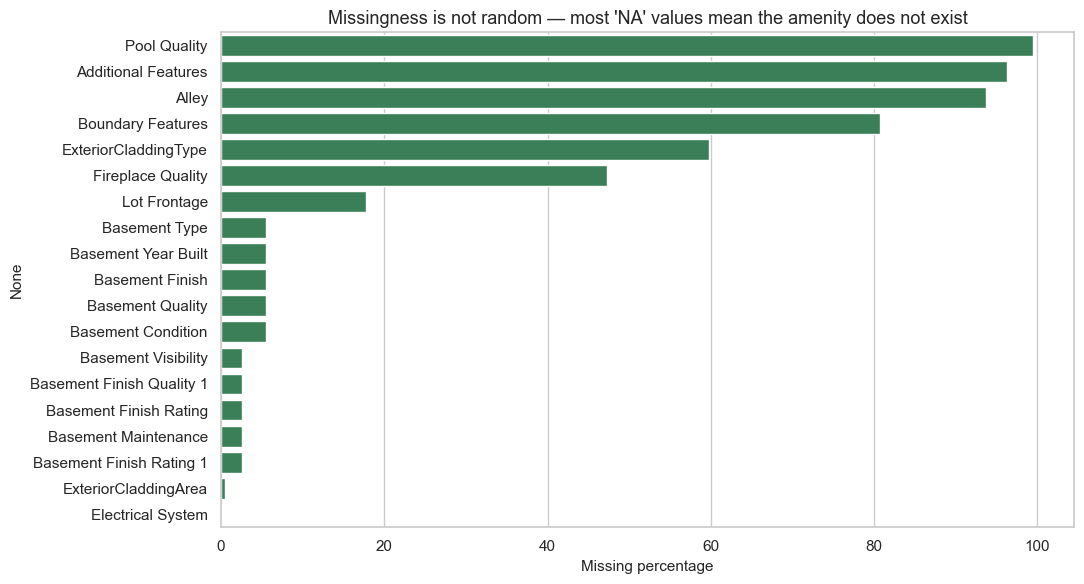

In [444]:
# Check total missing values in each column
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_tbl = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
print(f"{len(missing_tbl)} columns have missing values.\n")
display(missing_tbl)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(x=missing_pct.values, y=missing_pct.index, ax=ax, color = "seagreen")
ax.set_xlabel("Missing percentage")
ax.set_title("Missingness is not random — most 'NA' values mean the amenity does not exist")
plt.tight_layout()
plt.show()

### How to read the missingness

In this dataset, `NA` usually means **the feature is absent**, not that the surveyor forgot to fill it in:

| Column | Missing % | Real meaning |
|---|---|---|
| `PoolQC` | ~99.5% | Almost no houses have a pool |
| `Additional Features` | ~96% | No shed / tennis court / extra garage |
| `Alley` | ~94% | No alley access |
| `Boundary Features` | ~81% | No fence |
| `Fireplace Quality` | ~47% | No fireplace |
| Basement Type | ~5.5% | No garage |
| Basement Maintenance | ~2.5% | No basement |
| `Property[Lot] Frontage` | ~18% | **True missing** — street frontage was not recorded |
| `Electrical` | 1 row | **True missing** |

That distinction drives the fill strategy later. We will **not** drop `PoolQC` just because it is 99% empty. "No pool" is a valid, predictive category.

### Handling Missing Values

In [445]:
categorical_missing_columns = [
    "Pool Quality",
    "Additional Features",
    "Alley",
    "Boundary Features",
    "ExteriorCladdingType",
    "Fireplace Quality",
    "Basement Visibility",
    "Basement Finish",
    "Basement Maintenance",
    "Basement Finish Rating 1",
    "Basement Finish Quality 1",
    "Basement Type",
    "Basement Quality",
    "Basement Condition",
    "Basement Finish Rating"
]

for col in categorical_missing_columns:
    df[col] = df[col].fillna("None")

In [446]:
numerical_zero_columns = [
    "ExteriorCladdingArea",
    "Basement Year Built"
]

for col in numerical_zero_columns:
    df[col] = df[col].fillna(0)

In [447]:
df["Lot Frontage"] = df["Lot Frontage"].fillna(
    df["Lot Frontage"].median()
)

In [448]:
df["Electrical System"] = df["Electrical System"].fillna(
    df["Electrical System"].mode()[0]
)

In [449]:

missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_tbl = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
print(f"{len(missing_tbl)} columns have missing values.\n")

0 columns have missing values.



##### Now, we have 0 missing values.

###  Change datatype for required features

In [450]:
# Change datatype to integer

df["Basement Year Built"] = df["Basement Year Built"].astype("int64")

df["Lot Frontage"] = df["Lot Frontage"].astype("int64")

df["ExteriorCladdingArea"] = df["ExteriorCladdingArea"].astype("int64")

In [451]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column                               Non-Null Count  Dtype   
---  ------                               --------------  -----   
 0   Property Class                       1460 non-null   category
 1   Property Zone                        1460 non-null   object  
 2   Lot Frontage                         1460 non-null   int64   
 3   Property Size                        1460 non-null   int64   
 4   Street                               1460 non-null   object  
 5   Alley                                1460 non-null   object  
 6   Property[Lot] Shape                  1460 non-null   object  
 7   Land Contour[Elevation]              1460 non-null   object  
 8   Amenities                            1460 non-null   object  
 9   Lot Configuration                    1460 non-null   object  
 10  Land Slope                           1460 non-null   object  
 11  Neighborhood     

In [452]:
print("Target Property Price — the number we must predict\n")
print(df["Property Price"].describe())
print(f"\nSkewness: {df['Property Price'].skew():.3f}")
print(f"Median / Mean: {df['Property Price'].median():,.0f} / {df['Property Price'].mean():,.0f}")

Target Property Price — the number we must predict

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: Property Price, dtype: float64

Skewness: 1.883
Median / Mean: 163,000 / 180,921


# Step 7: Classify every column: numeric, ordinal, or nominal

The brief asks: *How can ordinal and nominal columns be handled separately?*

- **Ordinal** — categories with a meaningful rank (Excellent > Good > Typical > Fair)
- **Nominal** — labels with no rank (neighborhood names, roof style)
- **Numeric** — measured quantities (square feet, year, counts)

We build these lists from the Ames metadata, using the **actual column names in this file**.

In [453]:
# Quality / condition scale used across several fields
QUAL_5 = ["Ex", "Gd", "TA", "Fa", "Po"]


# Ordinal categorical columns
ORDINAL_COLS = [
    "Property[Lot] Shape",
    "Land Slope",
    "Exterior Quality",
    "Exterior Condition",
    "Basement Finish Rating",
    "Basement Maintenance",
    "Basement Visibility",
    "Basement Finish Rating 1",
    "Basement Finish Quality 1",
    "Heating Quality and Condition",
    "Kitchen Quality",
    "Functional",
    "Fireplace Quality",
    "Basement Finish",
    "Basement Quality",
    "Basement Condition",
    "Paved Driveway",
    "Pool Quality",
]


# Nominal categorical columns
NOMINAL_COLS = [
    "Property Class",
    "Property Zone",
    "Street",
    "Alley",
    "Land Contour[Elevation]",
    "Amenities",
    "Lot Configuration",
    "Neighborhood",
    "Condition 1",
    "Condition 2",
    "Building Type",
    "Property[House] Style",
    "Roof Style",
    "Roof Material",
    "Roof Material 1",
    "Roof Material 2",
    "ExteriorCladdingType",
    "Property Footing [Foundation] Type",
    "Heating Type",
    "Basement Type",
    "Boundary Features",
    "Additional Features",
    "Sale Type",
    "Sale Condition",
    "Electrical System",
    "Central Air Conditioning",
]


# Numerical columns
NUMERIC_COLS = [
    c for c in df.columns
    if c not in ORDINAL_COLS + NOMINAL_COLS + ["Property Price"]
]


print(f"Ordinal columns : {len(ORDINAL_COLS)}")
print(f"Nominal columns : {len(NOMINAL_COLS)}")
print(f"Numeric columns : {len(NUMERIC_COLS)}")
print(f"Target          : Property Price")

print(
    f"Accounted for   : "
    f"{len(ORDINAL_COLS) + len(NOMINAL_COLS) + len(NUMERIC_COLS) + 1} "
    f"/ {df.shape[1]}"
)


# Check if any column has not been classified
missing_from_lists = (
    set(df.columns)
    - set(ORDINAL_COLS)
    - set(NOMINAL_COLS)
    - set(NUMERIC_COLS)
    - {"Property Price"}
)

print(
    "Unclassified columns:",
    missing_from_lists if missing_from_lists else
    "None — every column is assigned."
)

Ordinal columns : 18
Nominal columns : 26
Numeric columns : 35
Target          : Property Price
Accounted for   : 80 / 80
Unclassified columns: None — every column is assigned.


# Step 8: Exploratory Data Analysis

EDA is where the story appears. We look at price first, then the features an agent would mention in a listing: living area, overall quality, neighborhood, age, and bathrooms.

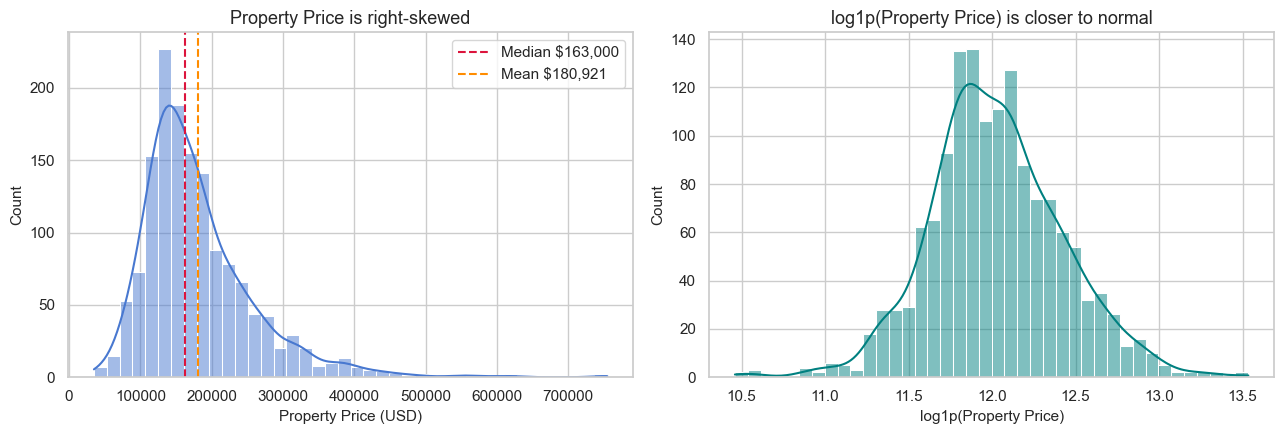

Raw skew = 1.883 | log1p skew = 0.121


In [454]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Raw Property Price distribution
sns.histplot(
    df["Property Price"],
    bins=40,
    kde=True,
    ax=axes[0]
)

axes[0].axvline(
    df["Property Price"].median(),
    color="crimson",
    ls="--",
    label=f"Median ${df['Property Price'].median():,.0f}"
)

axes[0].axvline(
    df["Property Price"].mean(),
    color="darkorange",
    ls="--",
    label=f"Mean ${df['Property Price'].mean():,.0f}"
)

axes[0].set_title("Property Price is right-skewed")
axes[0].set_xlabel("Property Price (USD)")
axes[0].legend()


# Log-transformed Property Price distribution
sns.histplot(
    np.log1p(df["Property Price"]),
    bins=40,
    kde=True, color="teal",
    ax=axes[1]
)

axes[1].set_title("log1p(Property Price) is closer to normal")
axes[1].set_xlabel("log1p(Property Price)")


plt.tight_layout()
plt.show()


# Skewness comparison
print(
    f"Raw skew = {df['Property Price'].skew():.3f} "
    f"| log1p skew = {np.log1p(df['Property Price']).skew():.3f}"
)

* **High Positive Skew:** Property prices are heavily right-skewed (**skew = 1.883**), where a small number of expensive homes drag the mean ($180,921) above the median ($163,000).
* **Effective Normalization:** Applying a `log1p` transformation compresses high-value outliers and drastically reduces skewness (**skew = 0.121**), creating a near-perfect bell curve.
* **Model Readiness:** Converting price data to a log scale stabilizes variance and satisfies the normality assumptions required for optimal performance in linear and regression models.

## 8.1 Size and quality — the two strongest listing facts

If we could tell a model only two things about a house, these would be them: **how big is the living area** and **how good is the finish**.

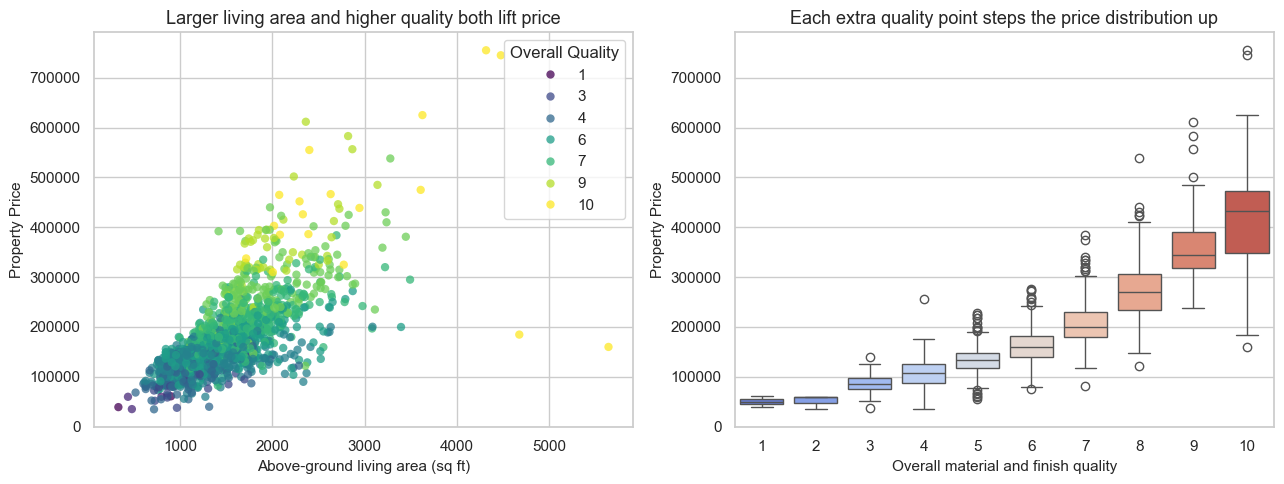

Correlation Above Ground Living Area vs Property Price: 0.709
Correlation Overall Quality vs Property Price: 0.791


In [455]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Above Ground Living Area vs Property Price
sns.scatterplot(
    data=df,
    x="Above Ground Living Area",
    y="Property Price",
    hue="Overall Quality",
    palette="viridis",
    alpha=0.75,
    ax=axes[0],
    edgecolor="none"
)

axes[0].set_title("Larger living area and higher quality both lift price")
axes[0].set_xlabel("Above-ground living area (sq ft)")
axes[0].set_ylabel("Property Price")


# Overall Quality vs Property Price
sns.boxplot(
    data=df,
    x="Overall Quality",
    y="Property Price",
    ax=axes[1],
    palette="coolwarm"
)

axes[1].set_title("Each extra quality point steps the price distribution up")
axes[1].set_xlabel("Overall material and finish quality")
axes[1].set_ylabel("Property Price")

plt.tight_layout()
plt.show()


# Correlation
print(
    "Correlation Above Ground Living Area vs Property Price:",
    df["Above Ground Living Area"].corr(
        df["Property Price"]
    ).round(3)
)

print(
    "Correlation Overall Quality vs Property Price:",
    df["Overall Quality"].corr(
        df["Property Price"]
    ).round(3)
)

**Reading the plot:** quality is almost a staircase. A 5/10 home and a 9/10 home are different markets. Living area matters, but a large low-quality house does not catch a small high-quality one. Two points on the far right (huge living area, modest price) look like outliers — we will flag them, not silently delete the column.

In [456]:
# Unusual sales: very large living area but relatively low price

large_cheap = df[
    (df["Above Ground Living Area"] > 4000) &
    (df["Property Price"] < 300000)
][
    [
        "Above Ground Living Area",
        "Overall Quality",
        "Neighborhood",
        "Year Built",
        "Sale Year",
        "Property Price"
    ]
]

print("Large living area but surprisingly low price (possible partial sales / anomalies):")
display(large_cheap)

Large living area but surprisingly low price (possible partial sales / anomalies):


,Above Ground Living Area,Overall Quality,Neighborhood,Year Built,Sale Year,Property Price
523,4676,10,Edwards,2007,2007,184750
1298,5642,10,Edwards,2008,2008,160000


## Step 8.3: Neighborhood is not a footnote

Ames is a collection of micro-markets. Northridge Heights and Stone Brook do not price like Old Town or IDOTRR.

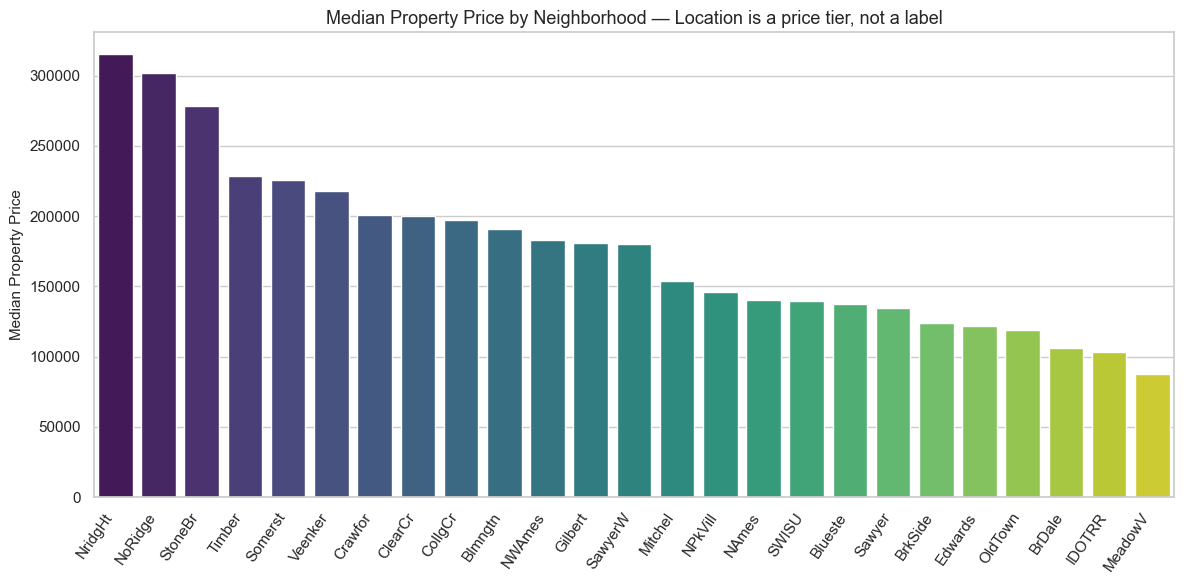

Most expensive neighborhoods:


,median_price,mean_price,n
Neighborhood,,,
NridgHt,"$315,000","$316,271",77
NoRidge,"$301,500","$335,295",41
StoneBr,"$278,000","$310,499",25
Timber,"$228,475","$242,247",38
Somerst,"$225,500","$225,380",86



Most affordable neighborhoods:


,median_price,mean_price,n
Neighborhood,,,
Edwards,"$121,750","$128,220",100
OldTown,"$119,000","$128,225",113
BrDale,"$106,000","$104,494",16
IDOTRR,"$103,000","$100,124",37
MeadowV,"$88,000","$98,576",17


In [457]:
nb_stats = (
    df.groupby("Neighborhood")["Property Price"]
    .agg(
        median_price="median",
        mean_price="mean",
        n="count"
    )
    .sort_values("median_price", ascending=False)
)


fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=nb_stats.reset_index(),
    x="Neighborhood",
    y="median_price",
    ax=ax,
    palette = "viridis", hue = "Neighborhood"
)

ax.set_title(
    "Median Property Price by Neighborhood — "
    "Location is a price tier, not a label"
)
ax.set_ylabel("Median Property Price")
ax.set_xlabel("")

plt.xticks(rotation=55, ha="right")
plt.tight_layout()
plt.show()


print("Most expensive neighborhoods:")
display(
    nb_stats.head(5).style.format({
        "median_price": "${:,.0f}",
        "mean_price": "${:,.0f}"
    })
)

print("\nMost affordable neighborhoods:")
display(
    nb_stats.tail(5).style.format({
        "median_price": "${:,.0f}",
        "mean_price": "${:,.0f}"
    })
)

## Step 8.4: Age, remodels, and when the house sold

A 1920 house that was gutted in 2008 is not the same asset as a 1920 house last touched in 1950. We look at original construction year, remodel year, and sale year.

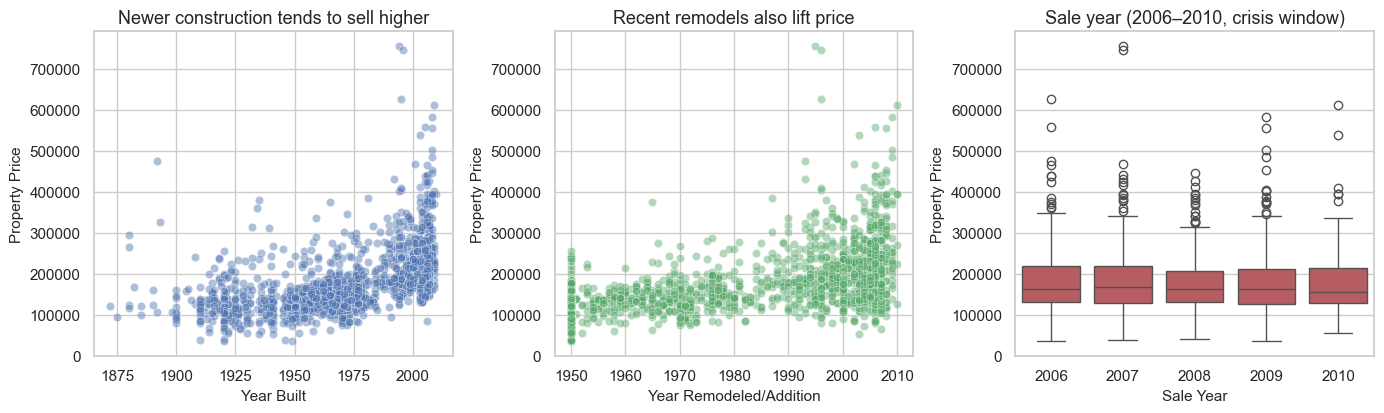

Median price by sale year:
Sale Year
2006    163995.0
2007    167000.0
2008    164000.0
2009    162000.0
2010    155000.0
Name: Property Price, dtype: float64


In [458]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))

# Year Built vs Property Price
sns.scatterplot(
    data=df,
    x="Year Built",
    y="Property Price",
    alpha=0.45,
    ax=axes[0],
    color="#4C72B0"
)
axes[0].set_title("Newer construction tends to sell higher")
axes[0].set_xlabel("Year Built")
axes[0].set_ylabel("Property Price")


# Year Remodeled vs Property Price
sns.scatterplot(
    data=df,
    x="Year Remodeled/Addition",
    y="Property Price",
    alpha=0.45,
    ax=axes[1],
    color="#55A868"
)
axes[1].set_title("Recent remodels also lift price")
axes[1].set_xlabel("Year Remodeled/Addition")
axes[1].set_ylabel("Property Price")


# Sale Year vs Property Price
sns.boxplot(
    data=df,
    x="Sale Year",
    y="Property Price",
    ax=axes[2],
    color="#C44E52"
)
axes[2].set_title("Sale year (2006–2010, crisis window)")
axes[2].set_xlabel("Sale Year")
axes[2].set_ylabel("Property Price")


plt.tight_layout()
plt.show()


print("Median price by sale year:")
print(
    df.groupby("Sale Year")["Property Price"].median()
)

## Step 8.5: Bathrooms, garage, and fireplaces — amenity counts 

These are the "how many?" questions on a listing sheet. They are numeric but behave like steps: the jump from 1 to 2 bathrooms is larger than the jump from 2 to 3.

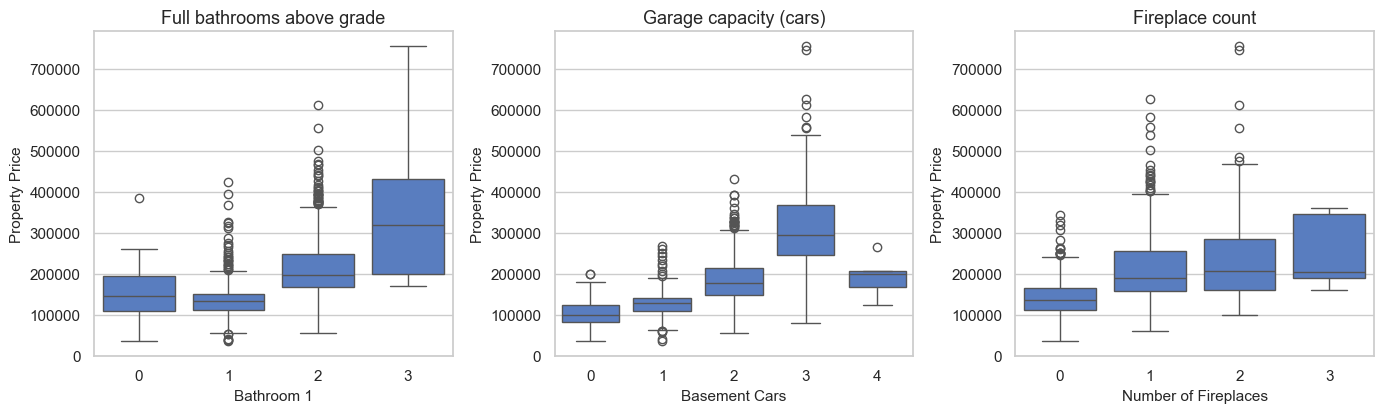

In [459]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))

sns.boxplot(
    data=df,
    x="Bathroom 1",
    y="Property Price",
    ax=axes[0]
)
axes[0].set_title("Full bathrooms above grade")
axes[0].set_xlabel("Bathroom 1")
axes[0].set_ylabel("Property Price")


sns.boxplot(
    data=df,
    x="Basement Cars",
    y="Property Price",
    ax=axes[1]
)
axes[1].set_title("Garage capacity (cars)")
axes[1].set_xlabel("Basement Cars")
axes[1].set_ylabel("Property Price")


sns.boxplot(
    data=df,
    x="Number of Fireplaces",
    y="Property Price",
    ax=axes[2]
)
axes[2].set_title("Fireplace count")
axes[2].set_xlabel("Number of Fireplaces")
axes[2].set_ylabel("Property Price")


plt.tight_layout()
plt.show()

* **Positive Correlation Across Features:** Property price consistently increases with higher counts of full bathrooms, garage capacity (cars), and fireplaces.
* **Diminishing Returns on Extreme Capacities:** For garage capacity, prices peak at 3 cars and drop off slightly at 4 cars, suggesting 4-car garages are rare or tied to older/niche properties rather than higher market value.
* **Outliers in Mid-Tier Properties:** Properties with 2 bathrooms, 2-3 car garages, or 1-2 fireplaces exhibit significant high-end outliers, reaching prices above $600k-$700k.

## Step 8.6: Kitchen and exterior quality — ordinal fields already speak

These columns are stored as text (`Ex`, `Gd`, `TA`, `Fa`) but they are ranked. EDA on the raw labels already shows a clean price ladder. That is why we will map them to integers instead of one-hot encoding them.

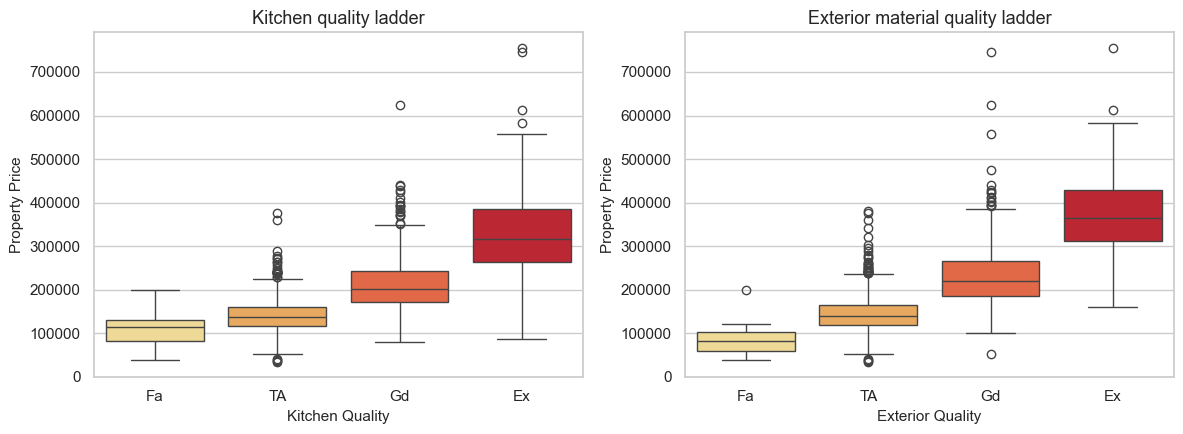

In [460]:
qual_order = ["Fa", "TA", "Gd", "Ex"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Kitchen Quality vs Property Price
sns.boxplot(
    data=df,
    x="Kitchen Quality",
    y="Property Price",
    order=qual_order,
    ax=axes[0],
    palette="YlOrRd"
)
axes[0].set_title("Kitchen quality ladder")
axes[0].set_xlabel("Kitchen Quality")
axes[0].set_ylabel("Property Price")


# Exterior Quality vs Property Price
sns.boxplot(
    data=df,
    x="Exterior Quality",
    y="Property Price",
    order=qual_order,
    ax=axes[1],
    palette="YlOrRd"
)
axes[1].set_title("Exterior material quality ladder")
axes[1].set_xlabel("Exterior Quality")
axes[1].set_ylabel("Property Price")


plt.tight_layout()
plt.show()

* **Strong Ordinal Correlation:** Both Kitchen and Exterior Quality show a clean, step-by-step price increase moving up the ordinal ladder from Fair (**Fa**) to Typical/Average (**TA**), Good (**Gd**), and Excellent (**Ex**).
* **Premium Spike for "Excellent":** Upgrading to **Ex** (Excellent) quality yields the highest price jump in both features, with median property prices rising sharply above $300,000–$350,000.
* **Luxury Outliers in Mid-High Tiers:** Significant top-tier price outliers exist within the **Gd** (Good) category across both charts, showing that exceptional properties can still command high prices even without top-grade kitchen or exterior finishes.

## Step 8.7: Correlation heatmap — which numbers move together?

We look at the numeric features most correlated with price. High correlation with the target is useful. High correlation *between predictors* (for example basement SF and first-floor SF) is why PCA and regularized linear models are worth trying later.

Top 15 numeric correlations with Property Price:
Overall Quality               0.791
Above Ground Living Area      0.709
Basement Cars                 0.640
Basement Area                 0.623
Basement Square Footage       0.614
First Floor Square Footage    0.606
Bathroom 1                    0.561
Total Rooms Above Ground      0.534
Year Built                    0.523
Year Remodeled/Addition       0.507
ExteriorCladdingArea          0.473
Number of Fireplaces          0.467
Basement Finish Style 1       0.386
Lot Frontage                  0.335
Wood Deck Square Footage      0.324
Name: Property Price, dtype: float64


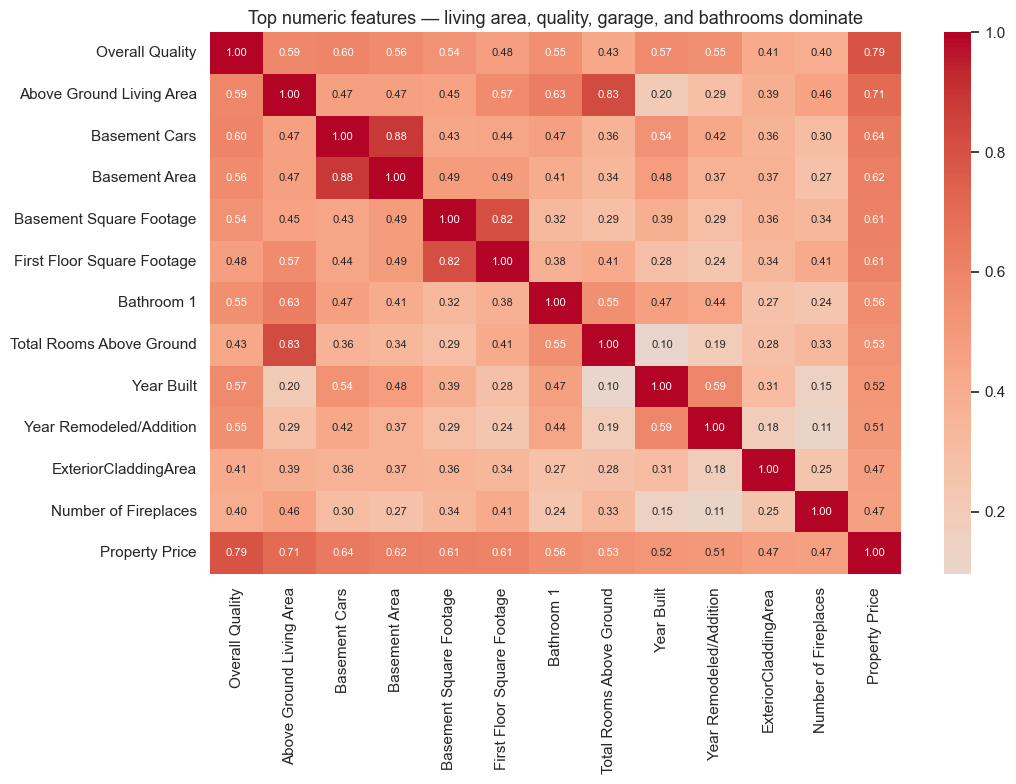

In [461]:
num_for_corr = df.select_dtypes(include=np.number).copy()

corr_target = (
    num_for_corr.corr()["Property Price"]
    .drop("Property Price")
    .sort_values(key=abs, ascending=False)
)

print("Top 15 numeric correlations with Property Price:")
print(corr_target.head(15).round(3))


top_feats = corr_target.head(12).index.tolist() + ["Property Price"]

fig, ax = plt.subplots(figsize=(11, 8))

sns.heatmap(
    num_for_corr[top_feats].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=ax,
    annot_kws={"size": 8}
)

ax.set_title(
    "Top numeric features — living area, quality, garage, and bathrooms dominate"
)

plt.tight_layout()
plt.show()

* **Primary Price Drivers:** **Overall Quality** ($r = 0.79$) and **Above Ground Living Area** ($r = 0.71$) show the strongest positive correlation with **Property Price**, making them the top target predictors.
* **Multicollinearity Risks:** High feature redundancy exists between **Basement Cars** & **Basement Area** ($r = 0.88$), **Basement Square Footage** & **First Floor Square Footage** ($r = 0.82$), and **Total Rooms Above Ground** & **Above Ground Living Area** ($r = 0.83$), indicating a need for feature drop or consolidation.
* **Secondary Price Factors:** Garage capacity, total square footage, and bathrooms maintain solid correlations ($0.56 - 0.64$) with price, while recency metrics (**Year Built** / **Year Remodeled**) carry moderate influence ($0.51 - 0.52$).

### What EDA tells us to engineer

The data is already telling a consistent story:

1. **Quality and living area** are the backbone of price
2. **Neighborhood** creates parallel markets
3. **Age and remodel recency** matter independently
4. **Garage, bathrooms, and fireplaces** add stepwise value
5. Several size fields overlap — total living area will be more stable than any single floor
6. A few giant, cheap houses look like partial sales; we will cap / flag them rather than drop columns

# Step 9: Feature Engineering

Feature engineering is where domain knowledge becomes columns. An appraiser does not look at `Year Built` and `Sale Year` separately and stop there — they compute **age at sale**. They do not look at four porch columns — they ask **how much outdoor living space is there?**

All of the features below are row-wise. They do not use other houses' statistics, so they can be created **before** the train/test split without leakage.

In [462]:
# Save original columns before feature engineering
original_cols = df.columns.tolist()


def engineer_features(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()

    # --- Age and remodel story ---
    out["HouseAge"] = (
        out["Sale Year"] - out["Year Built"]
    ).clip(lower=0)

    out["RemodAge"] = (
        out["Sale Year"] - out["Year Remodeled/Addition"]
    ).clip(lower=0)

    out["IsRemodeled"] = (
        out["Year Remodeled/Addition"] > out["Year Built"]
    ).astype(int)

    # --- Size story ---
    out["TotalSF"] = (
        out["Basement Square Footage"]
        + out["First Floor Square Footage"]
        + out["Second Floor Square Footage"]
    )

    out["TotalPorchSF"] = (
        out["Wood Deck Square Footage"]
        + out["Open Porch Square Footage"]
        + out["Enclosed Porch"]
        + out["Three Season Porch"]
        + out["Screen Porch"]
    )

    out["TotalBathrooms"] = (
        out["Bathroom 1"]
        + 0.5 * out["Bathroom 2"]
        + out["Basement Full Bathrooms"]
        + 0.5 * out["Basement Half Bathrooms"]
    )

    out["LivingAreaPerRoom"] = (
        out["Above Ground Living Area"]
        / out["Total Rooms Above Ground"].replace(0, np.nan)
    )

    out["LivingAreaPerRoom"] = out["LivingAreaPerRoom"].fillna(
        out["Above Ground Living Area"]
    )

    # --- Presence flags ---
    out["HasBasement"] = (
        out["Basement Square Footage"] > 0
    ).astype(int)

    out["HasGarage"] = (
        out["Basement Cars"] > 0
    ).astype(int)

    out["HasFireplace"] = (
        out["Number of Fireplaces"] > 0
    ).astype(int)

    out["HasPool"] = (
        out["Pool Area"] > 0
    ).astype(int)

    out["Has2ndFloor"] = (
        out["Second Floor Square Footage"] > 0
    ).astype(int)

    out["HasPorch"] = (
        out["TotalPorchSF"] > 0
    ).astype(int)

    out["HasMasonry"] = (
        out["ExteriorCladdingArea"].fillna(0) > 0
    ).astype(int)

    # --- Quality interactions ---
    out["QualLivArea"] = (
        out["Overall Quality"]
        * out["Above Ground Living Area"]
    )

    out["QualCond"] = (
        out["Overall Quality"]
        * out["Overall Condition"]
    )

    out["GarageScore"] = (
        out["Basement Cars"]
        * out["Basement Area"]
    )

    # --- Sale Month cyclic features ---
    month_map = {
        "Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4,
        "May": 5, "Jun": 6, "Jul": 7, "Aug": 8,
        "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12
    }

    sale_month_num = (
        out["Sale Month"]
        .astype(str)
        .str.strip()
        .str[:3]
        .map(month_map)
    )

    # If Sale Month is numeric, use numeric values
    sale_month_num = sale_month_num.fillna(
        pd.to_numeric(out["Sale Month"], errors="coerce")
    )

    out["SaleMonSin"] = np.sin(
        2 * np.pi * sale_month_num / 12
    )

    out["SaleMonCos"] = np.cos(
        2 * np.pi * sale_month_num / 12
    )

    return out


# Add engineered features directly to df
df = engineer_features(df)


# Identify newly created columns
new_cols = [
    c for c in df.columns
    if c not in original_cols
]

print(f"Created {len(new_cols)} engineered features:")
print(new_cols)

print("\nUpdated dataframe shape:", df.shape)

print("\nQuick check — new features vs Property Price:")

print(
    df[new_cols + ["Property Price"]]
    .corr()["Property Price"]
    .drop("Property Price")
    .sort_values(ascending=False)
    .round(3)
)

print("\nUpdated dataframe:")
display(df.head())

Created 19 engineered features:
['HouseAge', 'RemodAge', 'IsRemodeled', 'TotalSF', 'TotalPorchSF', 'TotalBathrooms', 'LivingAreaPerRoom', 'HasBasement', 'HasGarage', 'HasFireplace', 'HasPool', 'Has2ndFloor', 'HasPorch', 'HasMasonry', 'QualLivArea', 'QualCond', 'GarageScore', 'SaleMonSin', 'SaleMonCos']

Updated dataframe shape: (1460, 99)

Quick check — new features vs Property Price:
QualLivArea          0.832
TotalSF              0.782
GarageScore          0.680
TotalBathrooms       0.632
QualCond             0.565
LivingAreaPerRoom    0.541
HasFireplace         0.472
TotalPorchSF         0.391
HasMasonry           0.361
HasPorch             0.260
HasGarage            0.237
HasBasement          0.153
Has2ndFloor          0.138
HasPool              0.094
SaleMonCos           0.036
IsRemodeled         -0.022
SaleMonSin          -0.055
RemodAge            -0.509
HouseAge            -0.523
Name: Property Price, dtype: float64

Updated dataframe:


,Property Class,Property Zone,Lot Frontage,Property Size,Street,Alley,Property[Lot] Shape,Land Contour[Elevation],Amenities,Lot Configuration,Land Slope,Neighborhood,Condition 1,Condition 2,Building Type,Property[House] Style,Overall Quality,Overall Condition,Year Built,Year Remodeled/Addition,Roof Style,Roof Material,Roof Material 1,Roof Material 2,ExteriorCladdingType,ExteriorCladdingArea,Exterior Quality,Exterior Condition,Property Footing [Foundation] Type,Basement Finish Rating,Basement Maintenance,Basement Visibility,Basement Finish Rating 1,Basement Finish Style 1,Basement Finish Quality 1,Basement Finish Square Footage 2,Basement Unfinished Square Footage,Basement Square Footage,Heating Type,Heating Quality and Condition,Central Air Conditioning,Electrical System,First Floor Square Footage,Second Floor Square Footage,Low Quality Finished Square Footage,Above Ground Living Area,Basement Full Bathrooms,Basement Half Bathrooms,Bathroom 1,Bathroom 2,Bedrooms Upstairs,Kitchens Upstairs,Kitchen Quality,Total Rooms Above Ground,Functional,Number of Fireplaces,Fireplace Quality,Basement Type,Basement Year Built,Basement Finish,Basement Cars,Basement Area,Basement Quality,Basement Condition,Paved Driveway,Wood Deck Square Footage,Open Porch Square Footage,Enclosed Porch,Three Season Porch,Screen Porch,Pool Area,Pool Quality,Boundary Features,Additional Features,Additional Value,Sale Month,Sale Year,Sale Type,Sale Condition,Property Price,HouseAge,RemodAge,IsRemodeled,TotalSF,TotalPorchSF,TotalBathrooms,LivingAreaPerRoom,HasBasement,HasGarage,HasFireplace,HasPool,Has2ndFloor,HasPorch,HasMasonry,QualLivArea,QualCond,GarageScore,SaleMonSin,SaleMonCos
0,60,RL,65,8450,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,None,Attchd,2003,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,None,None,None,0,2,2008,WD,Normal,208500,5,5,0,2566,61,3.5,213.750000,1,1,0,0,1,1,1,11970,35,1096,8.660254e-01,5.000000e-01
1,20,RL,80,9600,Pave,None,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,None,None,None,0,5,2007,WD,Normal,181500,31,31,0,2524,298,2.5,210.333333,1,1,1,0,0,1,0,7572,48,920,5.000000e-01,-8.660254e-01
2,60,RL,68,11250,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,None,None,None,0,9,2008,WD,Normal,223500,7,6,1,2706,42,3.5,297.666667,1,1,1,0,1,1,1,12502,35,1216,-1.000000e+00,-1.836970e-16
3,70,RL,60,9550,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,None,None,None,0,2,2006,WD,Abnorml,140000,91,36,1,2473,307,2.0,245.285714,1,1,1,0,1,1,0,12019,35,1926,8.660254e-01,5.000000e-01
4,60,RL,84,14260,Pave,None,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,None,None,None,0,12,2008,WD,Normal,250000,8,8,0,3343,276,3.5,244.222222,1,1,1,0,1,1,1,17584,40,2508,-2.449294e-16,1.000000e+00


In [463]:
df.shape

(1460, 99)

In [464]:
print(df.columns.tolist())

['Property Class', 'Property Zone', 'Lot Frontage', 'Property Size', 'Street', 'Alley', 'Property[Lot] Shape', 'Land Contour[Elevation]', 'Amenities', 'Lot Configuration', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Building Type', 'Property[House] Style', 'Overall Quality', 'Overall Condition', 'Year Built', 'Year Remodeled/Addition', 'Roof Style', 'Roof Material', 'Roof Material 1', 'Roof Material 2', 'ExteriorCladdingType', 'ExteriorCladdingArea', 'Exterior Quality', 'Exterior Condition', 'Property Footing [Foundation] Type', 'Basement Finish Rating', 'Basement Maintenance', 'Basement Visibility', 'Basement Finish Rating 1', 'Basement Finish Style 1', 'Basement Finish Quality 1', 'Basement Finish Square Footage 2', 'Basement Unfinished Square Footage', 'Basement Square Footage', 'Heating Type', 'Heating Quality and Condition', 'Central Air Conditioning', 'Electrical System', 'First Floor Square Footage', 'Second Floor Square Footage', 'Low Quality Finished Square Fo

In [465]:
# Check unique values and uniqueness percentage for every column

uniqueness = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": [df[col].nunique(dropna=False) for col in df.columns],
    "Total Rows": len(df),
    "Uniqueness %": [
        round(df[col].nunique(dropna=False) / len(df) * 100, 2)
        for col in df.columns
    ],
    "Data Type": [df[col].dtype for col in df.columns]
})

uniqueness = uniqueness.sort_values(
    "Unique Values",
    ascending=False
)

display(uniqueness)

,Column,Unique Values,Total Rows,Uniqueness %,Data Type
94,QualLivArea,1133,1460,77.60,int64
3,Property Size,1073,1460,73.49,int64
86,LivingAreaPerRoom,993,1460,68.01,float64
83,TotalSF,963,1460,65.96,int64
45,Above Ground Living Area,861,1460,58.97,int64
36,Basement Unfinished Square Footage,780,1460,53.42,int64
42,First Floor Square Footage,753,1460,51.58,int64
37,Basement Square Footage,721,1460,49.38,int64
79,Property Price,663,1460,45.41,int64
33,Basement Finish Style 1,637,1460,43.63,int64


In [466]:
df.describe(include='all')

,Property Class,Property Zone,Lot Frontage,Property Size,Street,Alley,Property[Lot] Shape,Land Contour[Elevation],Amenities,Lot Configuration,Land Slope,Neighborhood,Condition 1,Condition 2,Building Type,Property[House] Style,Overall Quality,Overall Condition,Year Built,Year Remodeled/Addition,Roof Style,Roof Material,Roof Material 1,Roof Material 2,ExteriorCladdingType,ExteriorCladdingArea,Exterior Quality,Exterior Condition,Property Footing [Foundation] Type,Basement Finish Rating,Basement Maintenance,Basement Visibility,Basement Finish Rating 1,Basement Finish Style 1,Basement Finish Quality 1,Basement Finish Square Footage 2,Basement Unfinished Square Footage,Basement Square Footage,Heating Type,Heating Quality and Condition,Central Air Conditioning,Electrical System,First Floor Square Footage,Second Floor Square Footage,Low Quality Finished Square Footage,Above Ground Living Area,Basement Full Bathrooms,Basement Half Bathrooms,Bathroom 1,Bathroom 2,Bedrooms Upstairs,Kitchens Upstairs,Kitchen Quality,Total Rooms Above Ground,Functional,Number of Fireplaces,Fireplace Quality,Basement Type,Basement Year Built,Basement Finish,Basement Cars,Basement Area,Basement Quality,Basement Condition,Paved Driveway,Wood Deck Square Footage,Open Porch Square Footage,Enclosed Porch,Three Season Porch,Screen Porch,Pool Area,Pool Quality,Boundary Features,Additional Features,Additional Value,Sale Month,Sale Year,Sale Type,Sale Condition,Property Price,HouseAge,RemodAge,IsRemodeled,TotalSF,TotalPorchSF,TotalBathrooms,LivingAreaPerRoom,HasBasement,HasGarage,HasFireplace,HasPool,Has2ndFloor,HasPorch,HasMasonry,QualLivArea,QualCond,GarageScore,SaleMonSin,SaleMonCos
count,1460.0,1460,1460.000000,1460.000000,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460.000000,1460.000000,1460.000000,1460.000000,1460,1460,1460,1460,1460,1460.000000,1460,1460,1460,1460,1460,1460,1460,1460.000000,1460,1460.000000,1460.000000,1460.000000,1460,1460,1460,1460,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460,1460.000000,1460,1460.000000,1460,1460,1460.000000,1460,1460.000000,1460.000000,1460,1460,1460,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460,1460,1460,1460.000000,1460.000000,1460.000000,1460,1460,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1.460000e+03,1.460000e+03
unique,15.0,5,NaN,NaN,2,3,4,4,2,5,3,25,9,8,5,8,NaN,NaN,NaN,NaN,6,8,15,16,4,NaN,4,5,6,5,5,5,7,NaN,7,NaN,NaN,NaN,6,5,2,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,7,NaN,6,7,NaN,4,NaN,NaN,6,6,3,NaN,NaN,NaN,NaN,NaN,NaN,4,5,5,NaN,NaN,NaN,9,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,20.0,RL,NaN,NaN,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,NaN,NaN,NaN,NaN,Gable,CompShg,VinylSd,VinylSd,None,NaN,TA,TA,PConc,TA,TA,No,Unf,NaN,Unf,NaN,NaN,NaN,GasA,Ex,Y,SBrkr,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TA,NaN,Typ,NaN,None,Attchd,NaN,Unf,NaN,NaN,TA,TA,Y,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,NaN,NaN,NaN,WD,Normal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,536.0,1151,NaN,NaN,1454,1369,925,1311,1459,1052,1382,225,1260,1445,1220,726,NaN,NaN,NaN,NaN,1141,1434,515,504,872,NaN,906,1282,647,649,1311,953,430,NaN,1256,NaN,NaN,NaN,1428,741,1365,1335,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,735,NaN,1360,NaN,690,870,NaN,605,NaN,NaN,1311,1326,1340,NaN,NaN,NaN,NaN,NaN,NaN,1453,1179,1406,NaN,NaN,NaN,1267,1198,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,69.863699,10516.828082,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.099315,5.575342,1971.267808,1984.865753,NaN,NaN,NaN,NaN,NaN,103.117123,NaN,NaN,NaN,NaN,NaN,NaN,NaN,443.639726,NaN,46.549315,567.240411,1057.429452,NaN,NaN,NaN,NaN,116

### All engineered features

Total engineered features: 19
['HouseAge', 'RemodAge', 'IsRemodeled', 'TotalSF', 'TotalPorchSF', 'TotalBathrooms', 'LivingAreaPerRoom', 'HasBasement', 'HasGarage', 'HasFireplace', 'HasPool', 'Has2ndFloor', 'HasPorch', 'HasMasonry', 'QualLivArea', 'QualCond', 'GarageScore', 'SaleMonSin', 'SaleMonCos']


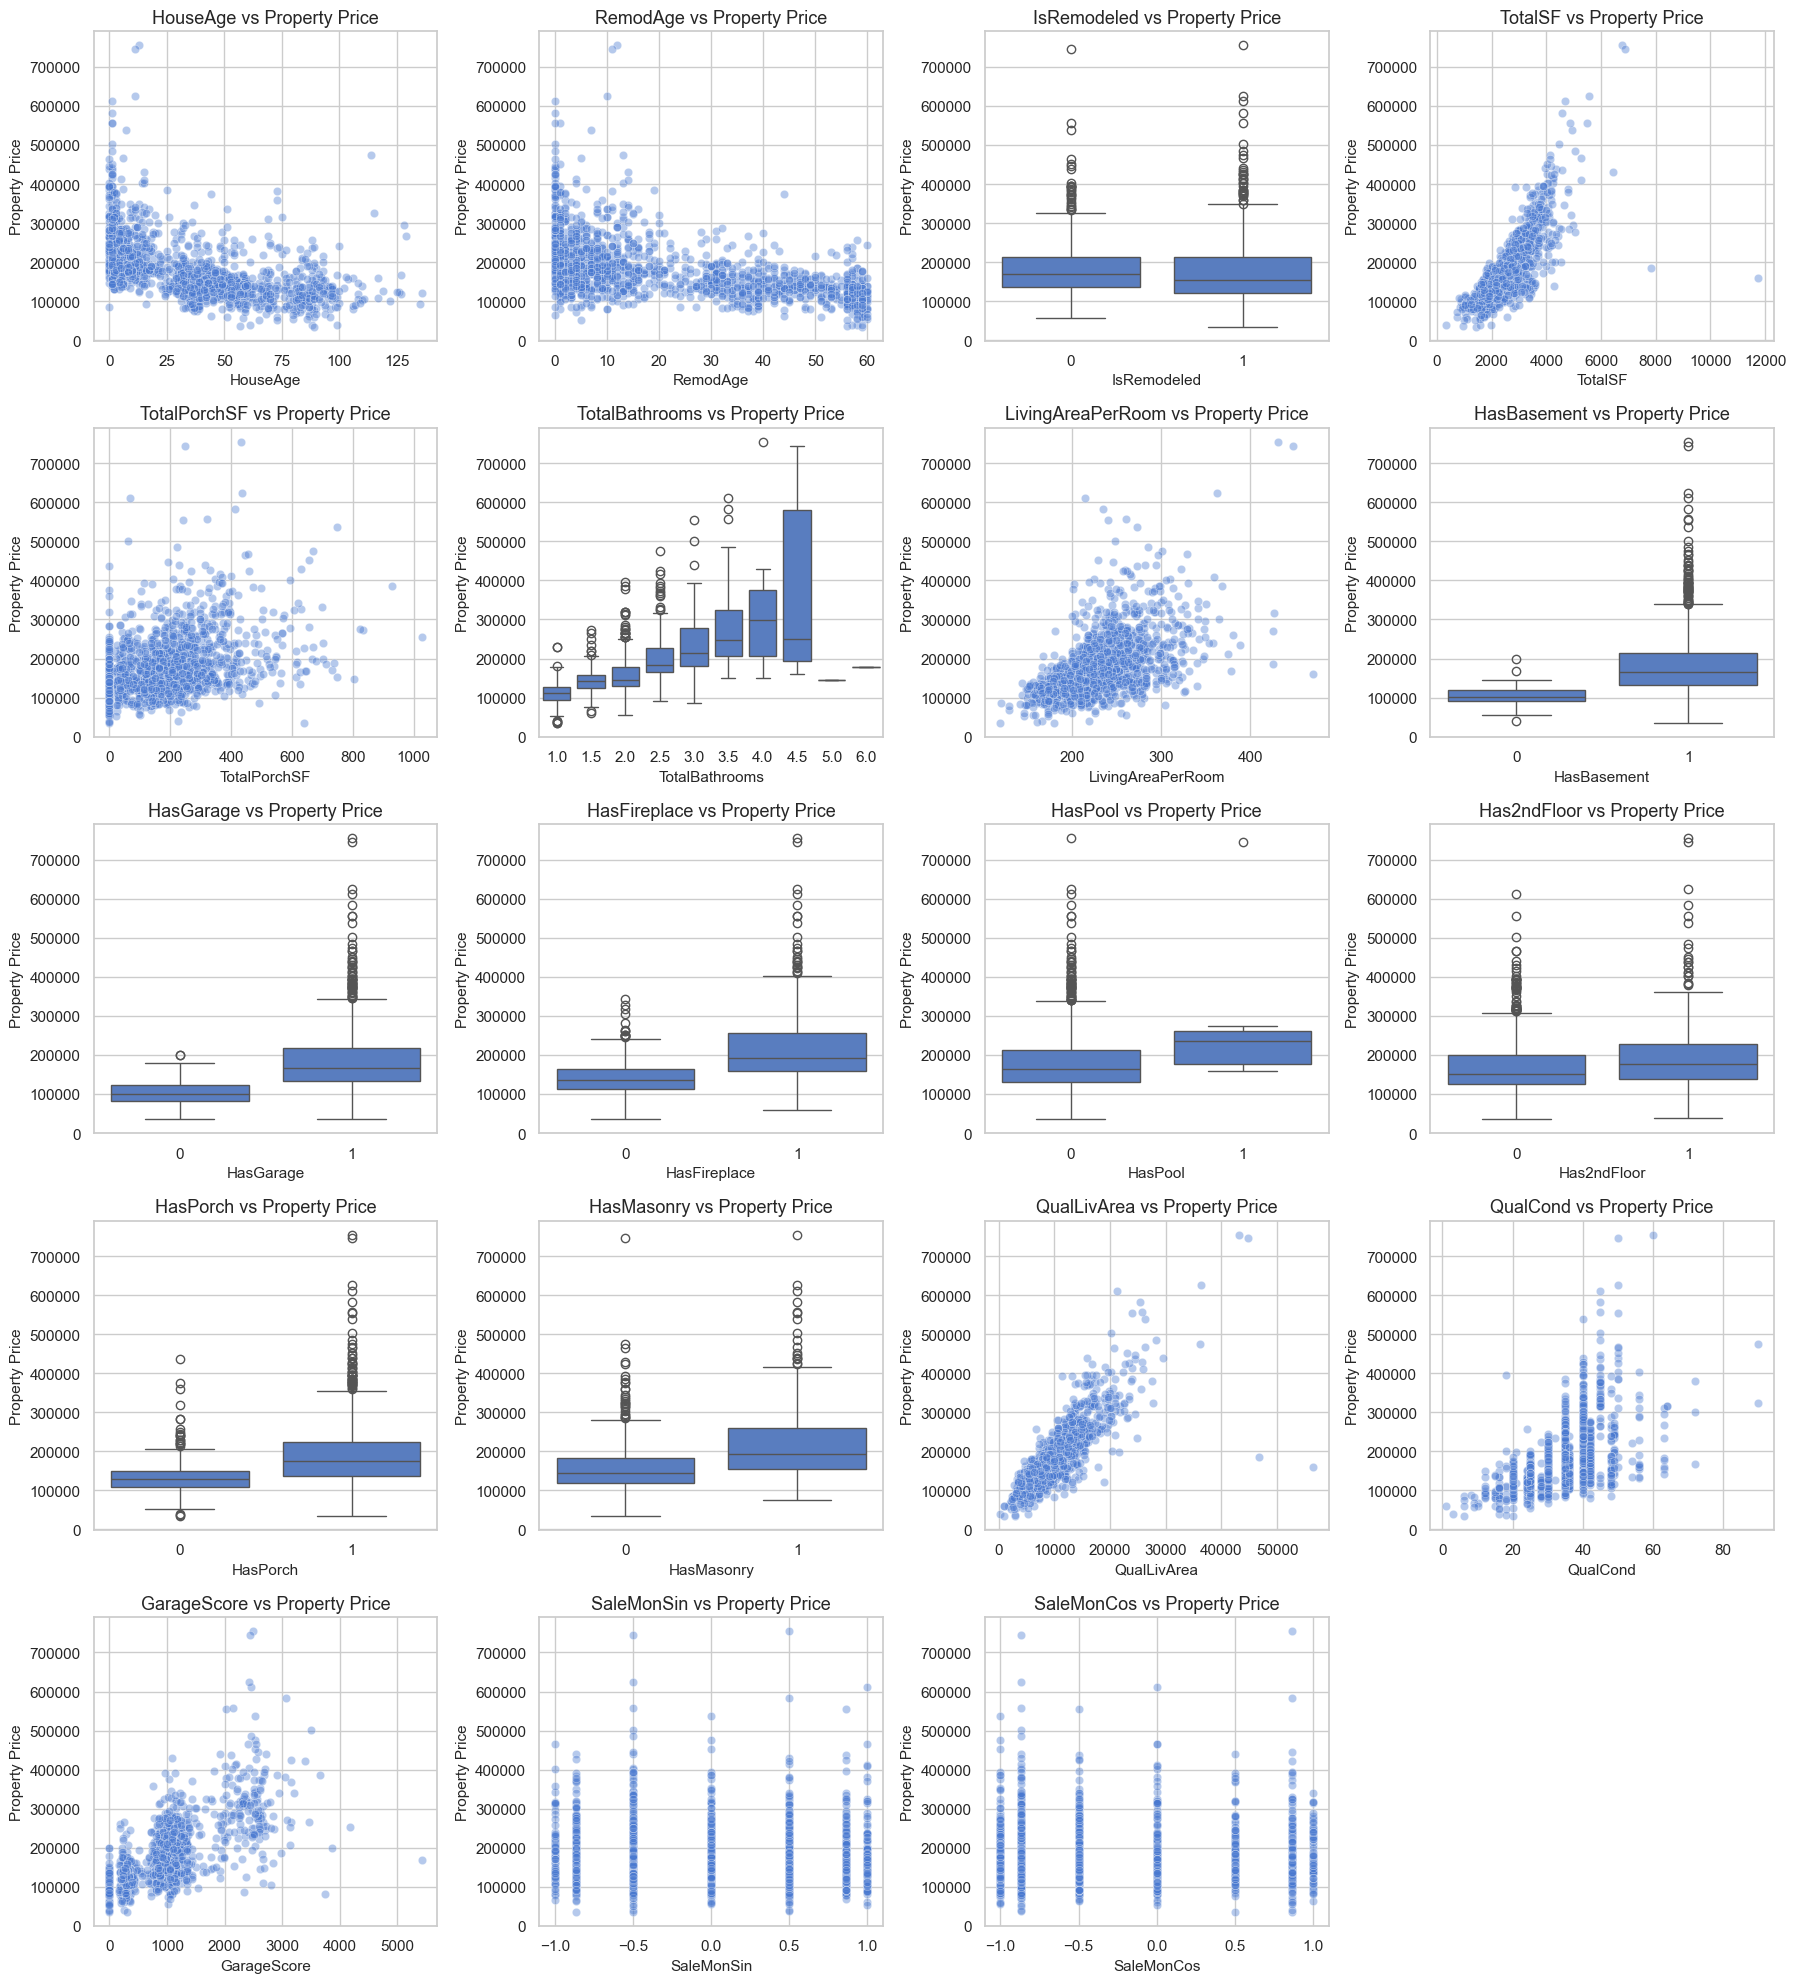

In [467]:
# All engineered features
engineered_cols = [
    c for c in df.columns
    if c not in original_cols
]

print(f"Total engineered features: {len(engineered_cols)}")
print(engineered_cols)


# Visualize relationship of every engineered feature with Property Price
n_cols = 4
n_rows = int(np.ceil(len(engineered_cols) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, n_rows * 4)
)

axes = np.array(axes).flatten()

for i, col in enumerate(engineered_cols):

    # Binary / categorical features
    if df[col].nunique(dropna=True) <= 10:

        sns.boxplot(
            data=df,
            x=col,
            y="Property Price",
            ax=axes[i]
        )

    # Continuous numerical features
    else:

        sns.scatterplot(
            data=df,
            x=col,
            y="Property Price",
            alpha=0.4,
            ax=axes[i]
        )

    axes[i].set_title(f"{col} vs Property Price")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Property Price")


# Remove unused plots
for j in range(len(engineered_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Engineered Feature Insights

- **QualLivArea shows the strongest positive relationship with Property Price**, indicating that the combination of overall quality and living area is highly associated with property value.
- **TotalSF, LivingAreaPerRoom, GarageScore, QualCond, and TotalBathrooms** also show clear positive relationships with property prices.
- **HouseAge and RemodAge show a negative relationship with price**, suggesting that newer and more recently remodeled properties generally tend to have higher values.
- Properties with a **basement, garage, fireplace, pool, second floor, porch, or masonry** generally have higher median prices than properties without these characteristics.
- **TotalPorchSF** shows a weaker and more dispersed positive relationship, suggesting that porch area has some influence but is not a dominant price factor.
- `IsRemodeled` alone does not show a strong separation in property prices, suggesting that remodeling status by itself may be less informative than the age of remodeling or other quality-related features.
- **SaleMonSin and SaleMonCos do not show a clear relationship with price**, indicating limited seasonal influence on property values.
- Some high-value and extreme observations are visible, particularly for `TotalSF`, `QualLivArea`, and other size-related features.

**Overall:** Feature engineering successfully captured meaningful information related to **property quality, usable space, age, structural characteristics, and amenities**, which can help improve property price prediction.

### Correlation of all engineered features with Property Price

In [468]:
# Correlation of all engineered features with Property Price

engineered_corr = (
    df[engineered_cols + ["Property Price"]]
    .corr(numeric_only=True)["Property Price"]
    .drop("Property Price")
    .sort_values(key=abs, ascending=False)
)

print("Engineered features ranked by correlation with Property Price:")
display(engineered_corr.round(3).to_frame("Correlation"))

Engineered features ranked by correlation with Property Price:


,Correlation
QualLivArea,0.832
TotalSF,0.782
GarageScore,0.680
TotalBathrooms,0.632
QualCond,0.565
LivingAreaPerRoom,0.541
HouseAge,-0.523
RemodAge,-0.509
HasFireplace,0.472
TotalPorchSF,0.391


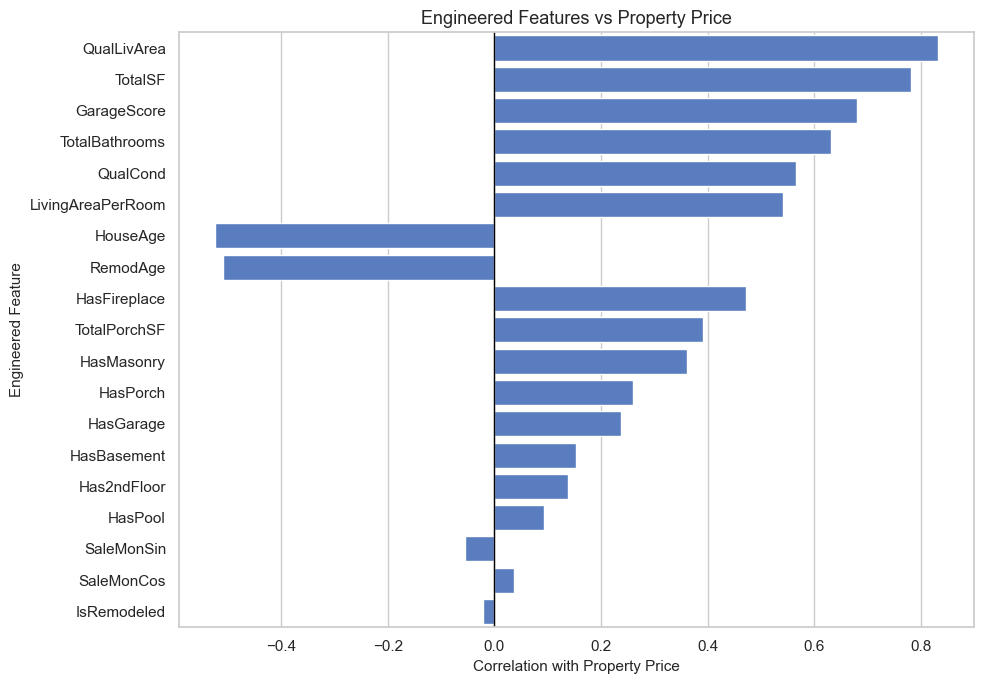

In [483]:
plt.figure(figsize=(10, 7))

sns.barplot(
    x=engineered_corr.values,
    y=engineered_corr.index
)

plt.axvline(0, color="black", linewidth=1)

plt.title("Engineered Features vs Property Price")
plt.xlabel("Correlation with Property Price")
plt.ylabel("Engineered Feature")

plt.tight_layout()
plt.show()

#### Property Price Drivers: Size, Age, and Bathrooms

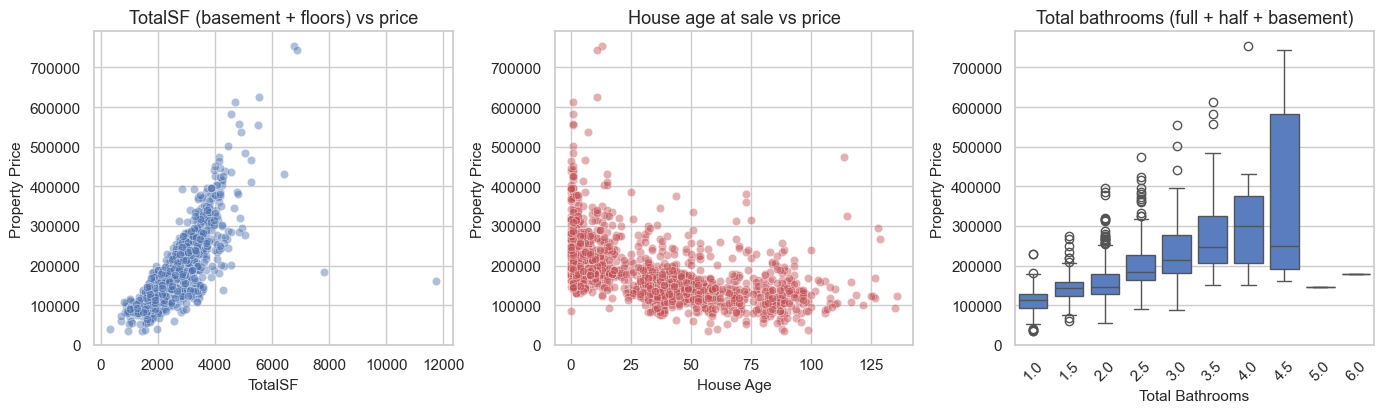

In [470]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))

# TotalSF vs Property Price
sns.scatterplot(
    data=df,
    x="TotalSF",
    y="Property Price",
    alpha=0.45,
    ax=axes[0],
    color="#4C72B0"
)
axes[0].set_title("TotalSF (basement + floors) vs price")
axes[0].set_xlabel("TotalSF")
axes[0].set_ylabel("Property Price")


# HouseAge vs Property Price
sns.scatterplot(
    data=df,
    x="HouseAge",
    y="Property Price",
    alpha=0.45,
    ax=axes[1],
    color="#C44E52"
)
axes[1].set_title("House age at sale vs price")
axes[1].set_xlabel("House Age")
axes[1].set_ylabel("Property Price")


# TotalBathrooms vs Property Price
sns.boxplot(
    data=df,
    x="TotalBathrooms",
    y="Property Price",
    ax=axes[2]
)
axes[2].set_title("Total bathrooms (full + half + basement)")
axes[2].set_xlabel("Total Bathrooms")
axes[2].set_ylabel("Property Price")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

`TotalSF` tightens the size-price relationship. `HouseAge` shows the expected decline, with a cluster of valuable old homes (character / location). `TotalBathrooms` is a cleaner amenity count than looking at four separate bath columns.

# Step 10: Feature Transformation — Label Encoding/One hot encoder

Convert all string/categorical columns into numeric labels so machine learning models can process them.

In [471]:
from sklearn.preprocessing import OrdinalEncoder

# ---------------------------------------------------------
# Feature Transformation
# Ordinal Encoding + One-Hot Encoding
# ---------------------------------------------------------

# 1. Identify categorical columns
categorical_cols = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

# Remove target if it is categorical (safety check)
if "Property Price" in categorical_cols:
    categorical_cols.remove("Property Price")


# 2. Separate ordinal and nominal categorical columns
ordinal_cols = [
    col for col in ORDINAL_COLS
    if col in categorical_cols
]

nominal_cols = [
    col for col in categorical_cols
    if col not in ordinal_cols
]


print("Ordinal categorical columns:")
print(ordinal_cols)

print("\nNominal categorical columns:")
print(nominal_cols)


# ---------------------------------------------------------
# 3. Ordinal Encoding
# ---------------------------------------------------------

# Mapping for quality-related columns
quality_order = {
    "Po": 1,
    "Fa": 2,
    "TA": 3,
    "Gd": 4,
    "Ex": 5
}

df_encoded = df.copy()

for col in ordinal_cols:

    # Use quality order where applicable
    if set(df[col].dropna().astype(str).unique()).issubset(
        set(quality_order.keys())
    ):
        df_encoded[col] = (
            df[col]
            .map(quality_order)
            .fillna(0)
            .astype(int)
        )

    else:
        # For other ordinal columns, use category codes
        df_encoded[col] = (
            df[col]
            .astype("category")
            .cat.codes
        )


# ---------------------------------------------------------
# 4. One-Hot Encoding for nominal categorical columns
# ---------------------------------------------------------

df_encoded = pd.get_dummies(
    df_encoded,
    columns=nominal_cols,
    drop_first=True,
    dtype=int
)


# ---------------------------------------------------------
# 5. Check result
# ---------------------------------------------------------

print("\nOriginal dataframe shape :", df.shape)
print("Encoded dataframe shape  :", df_encoded.shape)

print("\nRemaining categorical columns:")

remaining_cat = df_encoded.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print(remaining_cat)

print("\nFirst 5 rows of encoded dataframe:")
display(df_encoded.head())

Ordinal categorical columns:
['Property[Lot] Shape', 'Land Slope', 'Exterior Quality', 'Exterior Condition', 'Basement Finish Rating', 'Basement Maintenance', 'Basement Visibility', 'Basement Finish Rating 1', 'Basement Finish Quality 1', 'Heating Quality and Condition', 'Kitchen Quality', 'Functional', 'Fireplace Quality', 'Basement Finish', 'Basement Quality', 'Basement Condition', 'Paved Driveway', 'Pool Quality']

Nominal categorical columns:
['Property Class', 'Property Zone', 'Street', 'Alley', 'Land Contour[Elevation]', 'Amenities', 'Lot Configuration', 'Neighborhood', 'Condition 1', 'Condition 2', 'Building Type', 'Property[House] Style', 'Roof Style', 'Roof Material', 'Roof Material 1', 'Roof Material 2', 'ExteriorCladdingType', 'Property Footing [Foundation] Type', 'Heating Type', 'Central Air Conditioning', 'Electrical System', 'Basement Type', 'Boundary Features', 'Additional Features', 'Sale Type', 'Sale Condition']

Original dataframe shape : (1460, 99)
Encoded dataframe 

,Lot Frontage,Property Size,Property[Lot] Shape,Land Slope,Overall Quality,Overall Condition,Year Built,Year Remodeled/Addition,ExteriorCladdingArea,Exterior Quality,Exterior Condition,Basement Finish Rating,Basement Maintenance,Basement Visibility,Basement Finish Rating 1,Basement Finish Style 1,Basement Finish Quality 1,Basement Finish Square Footage 2,Basement Unfinished Square Footage,Basement Square Footage,Heating Quality and Condition,First Floor Square Footage,Second Floor Square Footage,Low Quality Finished Square Footage,Above Ground Living Area,Basement Full Bathrooms,Basement Half Bathrooms,Bathroom 1,Bathroom 2,Bedrooms Upstairs,Kitchens Upstairs,Kitchen Quality,Total Rooms Above Ground,Functional,Number of Fireplaces,Fireplace Quality,Basement Year Built,Basement Finish,Basement Cars,Basement Area,Basement Quality,Basement Condition,Paved Driveway,Wood Deck Square Footage,Open Porch Square Footage,Enclosed Porch,Three Season Porch,Screen Porch,Pool Area,Pool Quality,Additional Value,Sale Month,Sale Year,Property Price,HouseAge,RemodAge,IsRemodeled,TotalSF,TotalPorchSF,TotalBathrooms,...,Roof Material 2_AsphShn,Roof Material 2_Brk Cmn,Roof Material 2_BrkFace,Roof Material 2_CBlock,Roof Material 2_CmentBd,Roof Material 2_HdBoard,Roof Material 2_ImStucc,Roof Material 2_MetalSd,Roof Material 2_Other,Roof Material 2_Plywood,Roof Material 2_Stone,Roof Material 2_Stucco,Roof Material 2_VinylSd,Roof Material 2_Wd Sdng,Roof Material 2_Wd Shng,ExteriorCladdingType_BrkFace,ExteriorCladdingType_None,ExteriorCladdingType_Stone,Property Footing [Foundation] Type_CBlock,Property Footing [Foundation] Type_PConc,Property Footing [Foundation] Type_Slab,Property Footing [Foundation] Type_Stone,Property Footing [Foundation] Type_Wood,Heating Type_GasA,Heating Type_GasW,Heating Type_Grav,Heating Type_OthW,Heating Type_Wall,Central Air Conditioning_Y,Electrical System_FuseF,Electrical System_FuseP,Electrical System_Mix,Electrical System_SBrkr,Basement Type_Attchd,Basement Type_Basment,Basement Type_BuiltIn,Basement Type_CarPort,Basement Type_Detchd,Basement Type_None,Boundary Features_GdWo,Boundary Features_MnPrv,Boundary Features_MnWw,Boundary Features_None,Additional Features_None,Additional Features_Othr,Additional Features_Shed,Additional Features_TenC,Sale Type_CWD,Sale Type_Con,Sale Type_ConLD,Sale Type_ConLI,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_WD,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
0,65,8450,3,0,7,5,2003,2003,196,4,3,2,4,3,2,706,6,0,150,856,5,856,854,0,1710,1,0,2,1,3,1,4,8,6,0,3,2003,2,2,548,5,5,2,0,61,0,0,0,0,3,0,2,2008,208500,5,5,0,2566,61,3.5,...,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
1,80,9600,3,0,6,8,1976,1976,0,3,3,2,4,1,0,978,6,0,284,1262,5,1262,0,0,1262,0,1,2,0,3,1,3,6,6,1,5,1976,2,2,460,5,5,2,298,0,0,0,0,0,3,0,5,2007,181500,31,31,0,2524,298,2.5,...,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
2,68,11250,0,0,7,5,2001,2002,162,4,3,2,4,2,2,486,6,0,434,920,5,920,866,0,1786,1,0,2,1,3,1,4,6,6,1,5,2001,2,2,608,5,5,2,0,42,0,0,0,0,3,0,9,2008,223500,7,6,1,2706,42,3.5,...,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
3,60,9550,0,0,7,5,1915,1970,0,3,3,4,1,3,0,216,6,0,540,756,4,961,756,0,1717,1,0,1,0,3,1,4,7,6,1,2,1998,3,3,642,5,5,2,0,35,272,0,0,0,3,0,2,2006,140000,91,36,1,2473,307,2.0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
4,84,14260,0,0,8,5,2000,2000,350,4,3,2,4,0,2,655,6,0,490,1145,5,1145,1053,0,2198,1,0,2,1,4,1,4,9,6,1,5,2000,2,3,836,5,5,2,192,84,0,0,0,0,3,0,12,2008,250000,8,8,0,3343,276,3.5,...,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0


In [472]:
# Check remaining categorical columns

remaining_categorical = df_encoded.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Remaining categorical columns:")
print(remaining_categorical)

print("\nNumber of categorical columns remaining:",
      len(remaining_categorical))

Remaining categorical columns:
[]

Number of categorical columns remaining: 0


In [473]:
#final check of the dataframe shapes before and after encoding
print("Original df shape:", df.shape)
print("Encoded df shape:", df_encoded.shape)

Original df shape: (1460, 99)
Encoded df shape: (1460, 238)


# Step 11: Feature Scaling — Standardization & Normalization

Bring all numeric features to the **same scale** so no single feature dominates the model.

- **StandardScaler** → mean=0, std=1 (Standardization)  
- **MinMaxScaler** → range [0, 1] (Normalization)

In [474]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# ---------------------------------------------------------
# 1. Separate Features (X) and Target (y)
# ---------------------------------------------------------

X = df_encoded.drop(columns=["Property Price"])
y = df_encoded["Property Price"]


# ---------------------------------------------------------
# 2. Train-Test Split
# 80% Training | 20% Testing
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ---------------------------------------------------------
# 3. Standardization — StandardScaler
# Mean = 0, Standard Deviation = 1
# ---------------------------------------------------------

standard_scaler = StandardScaler()

X_train_standard = standard_scaler.fit_transform(X_train)
X_test_standard = standard_scaler.transform(X_test)


# ---------------------------------------------------------
# 4. Normalization — MinMaxScaler
# Range = [0, 1]
# ---------------------------------------------------------

minmax_scaler = MinMaxScaler()

X_train_minmax = minmax_scaler.fit_transform(X_train)
X_test_minmax = minmax_scaler.transform(X_test)


# ---------------------------------------------------------
# 5. Check results
# ---------------------------------------------------------

print("Original X_train shape :", X_train.shape)
print("Standardized X_train   :", X_train_standard.shape)
print("Normalized X_train     :", X_train_minmax.shape)

print("\nOriginal X_test shape  :", X_test.shape)
print("Standardized X_test    :", X_test_standard.shape)
print("Normalized X_test      :", X_test_minmax.shape)

print("\nTarget shapes:")
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

Original X_train shape : (1168, 237)
Standardized X_train   : (1168, 237)
Normalized X_train     : (1168, 237)

Original X_test shape  : (292, 237)
Standardized X_test    : (292, 237)
Normalized X_test      : (292, 237)

Target shapes:
y_train: (1168,)
y_test : (292,)


# Step 12: PCA — compressing correlated size and quality signals

Living area, first-floor SF, basement SF, room count, and quality interactions overlap. PCA finds a smaller set of uncorrelated components that still explain most of the variance.

We do **not** replace the original features for every model. Trees often prefer the raw engineered columns. We will:

1. Inspect explained variance
2. Keep enough components to retain **95%** of train variance
3. Train a linear model on PCA features as one of the candidates

STEP 12: PRINCIPAL COMPONENT ANALYSIS (PCA)


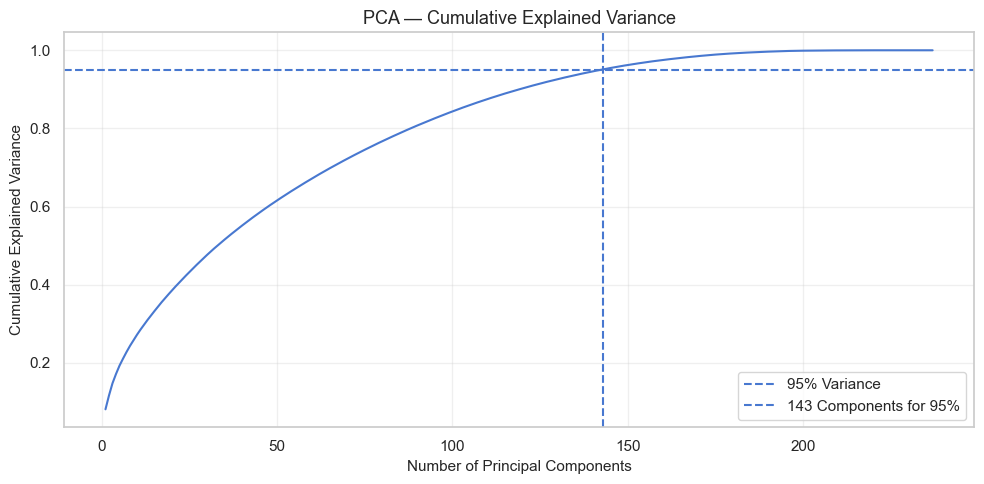

Original encoded features : 237
Components for 95% variance: 143
Components for 99% variance: 177
Variance in first 10 PCs   : 27.24%

PCA Dataset Shapes:
Training: (1168, 143)
Testing : (292, 143)
Variance Retained: 95.08%


In [475]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

print('=' * 60)
print('STEP 12: PRINCIPAL COMPONENT ANALYSIS (PCA)')
print('=' * 60)


# ---------------------------------------------------------
# 1. Fit PCA on Standardized Training Data
# ---------------------------------------------------------

pca_full = PCA()

pca_full.fit(X_train_standard)

cum_var = np.cumsum(
    pca_full.explained_variance_ratio_
)


# ---------------------------------------------------------
# 2. Find Components for 95% and 99% Variance
# ---------------------------------------------------------

n95 = int(
    np.searchsorted(cum_var, 0.95) + 1
)

n99 = int(
    np.searchsorted(cum_var, 0.99) + 1
)


# ---------------------------------------------------------
# 3. Plot Cumulative Explained Variance
# ---------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(cum_var) + 1),
    cum_var
)

plt.axhline(
    y=0.95,
    linestyle='--',
    label='95% Variance'
)

plt.axvline(
    x=n95,
    linestyle='--',
    label=f'{n95} Components for 95%'
)

plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — Cumulative Explained Variance')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 4. PCA Summary
# ---------------------------------------------------------

print(
    f'Original encoded features : '
    f'{X_train_standard.shape[1]}'
)

print(
    f'Components for 95% variance: {n95}'
)

print(
    f'Components for 99% variance: {n99}'
)

print(
    f'Variance in first 10 PCs   : '
    f'{cum_var[9] * 100:.2f}%'
)


# ---------------------------------------------------------
# 5. Create Final PCA Dataset — 95% Variance
# ---------------------------------------------------------

pca_95 = PCA(n_components=n95)

X_train_pca = pca_95.fit_transform(
    X_train_standard
)

X_test_pca = pca_95.transform(
    X_test_standard
)


print('\nPCA Dataset Shapes:')
print('Training:', X_train_pca.shape)
print('Testing :', X_test_pca.shape)

print(
    f'Variance Retained: '
    f'{pca_95.explained_variance_ratio_.sum() * 100:.2f}%'
)

### PCA Insights

- The encoded dataset originally contained **238 features**.
- PCA reduced the feature space to **143 principal components** while retaining approximately **95.10% of the total variance**.
- This represents a reduction of **95 dimensions**, or approximately **40% of the original feature space**, with only about **4.90% variance discarded**.
- To retain **99% of the variance**, **177 principal components** would be required. Therefore, the 95% threshold provides a better balance between dimensionality reduction and information retention.
- The first **10 principal components explain only 27.49% of the total variance**, indicating that the information in the dataset is distributed across many dimensions rather than being concentrated in only a few components.
- The cumulative explained variance curve increases gradually and reaches the selected **95% threshold at 143 components**, which supports the chosen number of components.
- PCA was fitted only on the standardized training data and the same transformation was applied to the test data, preventing data leakage.
- The resulting PCA datasets contain **143 components**, with **1,168 training observations** and **292 testing observations**.

**Conclusion:** PCA achieved meaningful dimensionality reduction while preserving most of the information present in the encoded features. The PCA-transformed data can now be evaluated with a linear regression model and compared against models trained using the original feature space.

In [476]:
# ---------------------------------------------------------
# Create Final PCA Dataset — 95% Variance
# ---------------------------------------------------------

pca = PCA(n_components=n95)

# Fit PCA only on standardized training data
X_train_pca = pca.fit_transform(X_train_standard)

# Apply same transformation to test data
X_test_pca = pca.transform(X_test_standard)


# ---------------------------------------------------------
# Check PCA Results
# ---------------------------------------------------------

print(
    f"PCA train shape: {X_train_pca.shape}   "
    f"PCA test shape: {X_test_pca.shape}"
)

print(
    f"Retained variance: "
    f"{pca.explained_variance_ratio_.sum():.4f}"
)

PCA train shape: (1168, 143)   PCA test shape: (292, 143)
Retained variance: 0.9508


### PCA Result

PCA reduced the original **238 encoded features to 143 principal components** while retaining approximately **95.10% of the total variance**.

The transformed training and testing datasets have shapes **(1168, 143)** and **(292, 143)** respectively. This indicates that PCA successfully reduced the dimensionality of the dataset while preserving most of the information required for modeling.

# Step 13: Log Transform Target

In [477]:
# ---------------------------------------------------------
# STEP 13: LOG TRANSFORMATION OF TARGET
# ---------------------------------------------------------

import numpy as np

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print('=' * 60)
print('STEP 13: LOG TRANSFORMATION OF TARGET')
print('=' * 60)

print(f'Original y_train range : {y_train.min():,.0f} to {y_train.max():,.0f}')
print(f'Log y_train range      : {y_train_log.min():.4f} to {y_train_log.max():.4f}')

print('\n✔ Property Price transformed using log1p()')

STEP 13: LOG TRANSFORMATION OF TARGET
Original y_train range : 34,900 to 745,000
Log y_train range      : 10.4603 to 13.5211

✔ Property Price transformed using log1p()


# Step 14: Model Building

The project evaluates multiple regression algorithms to identify the most suitable model for property price prediction.

The models include **Linear Regression, Ridge Regression, Lasso Regression, Decision Tree, Random Forest, Gradient Boosting, and Ridge Regression with PCA**. Regularized linear models such as Ridge and Lasso are included to handle the high-dimensional encoded feature space, while tree-based and boosting models are used to capture nonlinear relationships and feature interactions.

Since the target variable, **Property Price**, is right-skewed, the models are trained to predict the **log-transformed property price (`log1p`)**. During evaluation, the predicted log prices are converted back to the original price scale using **`expm1()`**.

This allows model performance to be evaluated using **MAE, RMSE, and R²** on the original property price scale, making the results easier to interpret in real-world terms.

Additionally, **Ridge + PCA** is evaluated to determine whether dimensionality reduction can maintain predictive performance while using fewer features.

In [478]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

print('=' * 60)
print('STEP 14: MODEL Building')
print('=' * 60)


# ---------------------------------------------------------
# 1. Linear Regression
# Standardized features
# ---------------------------------------------------------

linear_model = LinearRegression()

linear_model.fit(
    X_train_standard,
    y_train_log
)

print('✔ Linear Regression trained')


# ---------------------------------------------------------
# 2. Ridge Regression
# Standardized features
# ---------------------------------------------------------

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(
    X_train_standard,
    y_train_log
)

print('✔ Ridge Regression trained')


# ---------------------------------------------------------
# 3. Lasso Regression
# Standardized features
# ---------------------------------------------------------

lasso_model = Lasso(
    alpha=0.001,
    max_iter=10000
)

lasso_model.fit(
    X_train_standard,
    y_train_log
)

print('✔ Lasso Regression trained')


# ---------------------------------------------------------
# 4. Decision Tree
# Original encoded features
# ---------------------------------------------------------

dt_model = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

dt_model.fit(
    X_train,
    y_train_log
)

print('✔ Decision Tree trained')


# ---------------------------------------------------------
# 5. Random Forest
# Original encoded features
# ---------------------------------------------------------

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train_log
)

print('✔ Random Forest trained')


# ---------------------------------------------------------
# 6. Gradient Boosting
# Original encoded features
# ---------------------------------------------------------

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(
    X_train,
    y_train_log
)

print('✔ Gradient Boosting trained')


# ---------------------------------------------------------
# 7. Ridge + PCA
# PCA-transformed features
# ---------------------------------------------------------

ridge_pca_model = Ridge(alpha=1.0)

ridge_pca_model.fit(
    X_train_pca,
    y_train_log
)

print('✔ Ridge + PCA trained')


print('\n' + '=' * 60)
print('ALL 14 MODELS TRAINED SUCCESSFULLY')
print('=' * 60)

STEP 14: MODEL Building
✔ Linear Regression trained
✔ Ridge Regression trained
✔ Lasso Regression trained
✔ Decision Tree trained
✔ Random Forest trained
✔ Gradient Boosting trained
✔ Ridge + PCA trained

ALL 14 MODELS TRAINED SUCCESSFULLY


# Step 15: Model Evalution


The models are evaluated using **MAE, RMSE, and R²** on the original property price scale (USD).

- **MAE (Mean Absolute Error):** Answers, *"On average, how many dollars is the predicted property price away from the actual price?"*

- **RMSE (Root Mean Squared Error):** Gives more weight to large prediction errors, making it useful for identifying models that badly underpredict or overpredict expensive properties.

- **R² (Coefficient of Determination):** Indicates how much of the variation in property prices is explained by the model. A higher R² generally indicates better predictive performance.

STEP 15: MODEL EVALUATION AND COMPARISON

Model Performance:

Linear Regression    MAE=$16,112   RMSE=$25,597   R2=0.9146
Ridge Regression     MAE=$16,148   RMSE=$25,877   R2=0.9127
Lasso Regression     MAE=$15,715   RMSE=$25,894   R2=0.9126
Ridge + PCA          MAE=$16,949   RMSE=$26,860   R2=0.9059
Gradient Boosting    MAE=$16,850   RMSE=$29,477   R2=0.8867
Random Forest        MAE=$17,366   RMSE=$31,379   R2=0.8716
Decision Tree        MAE=$24,324   RMSE=$38,784   R2=0.8039

Leaderboard (Test Set — Prices in USD):



,Model,MAE,RMSE,R2,R2_pct
0,Linear Regression,16112.0,25597.0,0.9146,91.46
1,Ridge Regression,16148.0,25877.0,0.9127,91.27
2,Lasso Regression,15715.0,25894.0,0.9126,91.26
3,Ridge + PCA,16949.0,26860.0,0.9059,90.59
4,Gradient Boosting,16850.0,29477.0,0.8867,88.67
5,Random Forest,17366.0,31379.0,0.8716,87.16
6,Decision Tree,24324.0,38784.0,0.8039,80.39


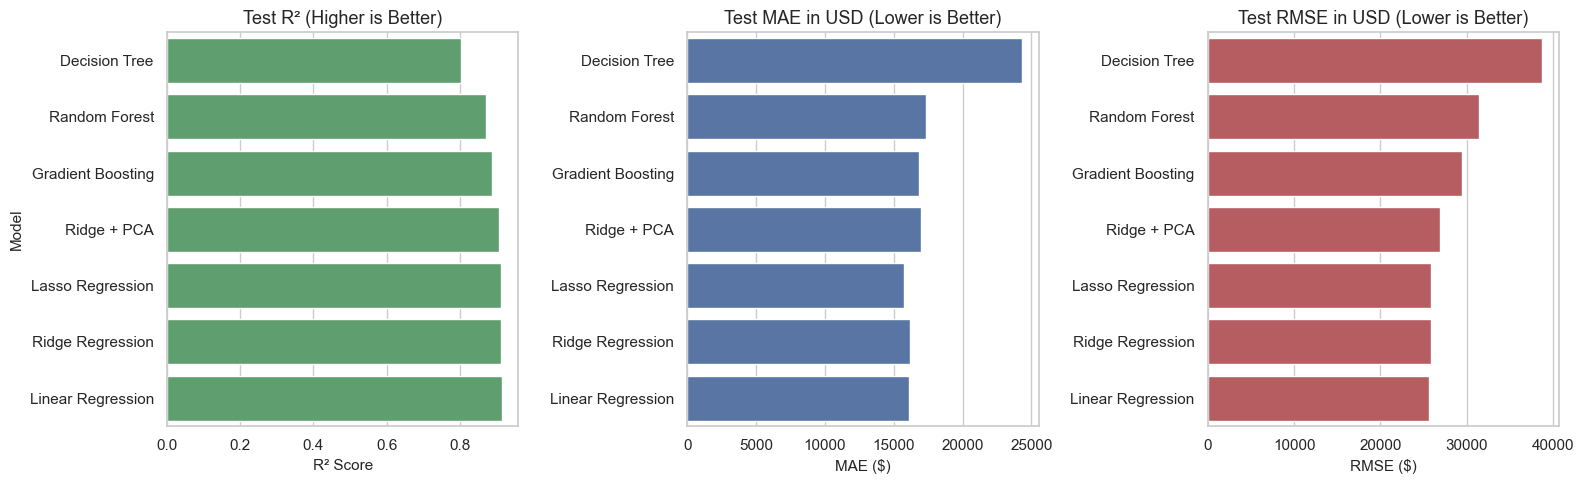

Best model on the test set: Linear Regression | R² = 0.9146 (91.46%)


In [479]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

print('=' * 70)
print('STEP 15: MODEL EVALUATION AND COMPARISON')
print('=' * 70)


# ---------------------------------------------------------
# Function to Convert Log Predictions Back to USD
# ---------------------------------------------------------

def dollars_from_log(pred_log):
    return np.expm1(pred_log)


# ---------------------------------------------------------
# Evaluation Function
# ---------------------------------------------------------

def evaluate_model(name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(y_true, y_pred)

    return {
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    }


# ---------------------------------------------------------
# Store Results and Predictions
# ---------------------------------------------------------

results = []
predictions = {}


# ---------------------------------------------------------
# 1. Linear Regression
# ---------------------------------------------------------

pred_log = linear_model.predict(X_test_standard)
pred = dollars_from_log(pred_log)

predictions['Linear Regression'] = pred

results.append(
    evaluate_model(
        'Linear Regression',
        y_test,
        pred
    )
)


# ---------------------------------------------------------
# 2. Ridge Regression
# ---------------------------------------------------------

pred_log = ridge_model.predict(X_test_standard)
pred = dollars_from_log(pred_log)

predictions['Ridge Regression'] = pred

results.append(
    evaluate_model(
        'Ridge Regression',
        y_test,
        pred
    )
)


# ---------------------------------------------------------
# 3. Lasso Regression
# ---------------------------------------------------------

pred_log = lasso_model.predict(X_test_standard)
pred = dollars_from_log(pred_log)

predictions['Lasso Regression'] = pred

results.append(
    evaluate_model(
        'Lasso Regression',
        y_test,
        pred
    )
)


# ---------------------------------------------------------
# 4. Decision Tree
# ---------------------------------------------------------

pred_log = dt_model.predict(X_test)
pred = dollars_from_log(pred_log)

predictions['Decision Tree'] = pred

results.append(
    evaluate_model(
        'Decision Tree',
        y_test,
        pred
    )
)


# ---------------------------------------------------------
# 5. Random Forest
# ---------------------------------------------------------

pred_log = rf_model.predict(X_test)
pred = dollars_from_log(pred_log)

predictions['Random Forest'] = pred

results.append(
    evaluate_model(
        'Random Forest',
        y_test,
        pred
    )
)


# ---------------------------------------------------------
# 6. Gradient Boosting
# ---------------------------------------------------------

pred_log = gb_model.predict(X_test)
pred = dollars_from_log(pred_log)

predictions['Gradient Boosting'] = pred

results.append(
    evaluate_model(
        'Gradient Boosting',
        y_test,
        pred
    )
)


# ---------------------------------------------------------
# 7. Ridge + PCA
# ---------------------------------------------------------

pred_log = ridge_pca_model.predict(X_test_pca)
pred = dollars_from_log(pred_log)

predictions['Ridge + PCA'] = pred

results.append(
    evaluate_model(
        'Ridge + PCA',
        y_test,
        pred
    )
)


# ---------------------------------------------------------
# Create Leaderboard
# ---------------------------------------------------------

results_df = pd.DataFrame(results)

results_df = (
    results_df
    .sort_values(
        by='R2',
        ascending=False
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------
# Format Results
# ---------------------------------------------------------

results_df['MAE'] = results_df['MAE'].round(0)
results_df['RMSE'] = results_df['RMSE'].round(0)
results_df['R2'] = results_df['R2'].round(4)
results_df['R2_pct'] = (
    results_df['R2'] * 100
).round(2)


# ---------------------------------------------------------
# Display Individual Results
# ---------------------------------------------------------

print('\nModel Performance:\n')

for _, row in results_df.iterrows():

    print(
        f"{row['Model']:<20} "
        f"MAE=${row['MAE']:,.0f}   "
        f"RMSE=${row['RMSE']:,.0f}   "
        f"R2={row['R2']:.4f}"
    )


# ---------------------------------------------------------
# Final Leaderboard
# ---------------------------------------------------------

print('\nLeaderboard (Test Set — Prices in USD):\n')

display(results_df)

# ---------------------------------------------------------
# Model Performance Visualization
# ---------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Sort models by R²
plot_df = results_df.sort_values("R2", ascending=True)


# ---------------------------------------------------------
# R² Comparison
# ---------------------------------------------------------

sns.barplot(
    data=plot_df,
    y="Model",
    x="R2",
    ax=axes[0],
    color="#55A868"
)

axes[0].set_title("Test R² (Higher is Better)")
axes[0].set_xlabel("R² Score")
axes[0].set_ylabel("Model")


# ---------------------------------------------------------
# MAE Comparison
# ---------------------------------------------------------

sns.barplot(
    data=plot_df,
    y="Model",
    x="MAE",
    ax=axes[1],
    color="#4C72B0"
)

axes[1].set_title("Test MAE in USD (Lower is Better)")
axes[1].set_xlabel("MAE ($)")
axes[1].set_ylabel("")


# ---------------------------------------------------------
# RMSE Comparison
# ---------------------------------------------------------

sns.barplot(
    data=plot_df,
    y="Model",
    x="RMSE",
    ax=axes[2],
    color="#C44E52"
)

axes[2].set_title("Test RMSE in USD (Lower is Better)")
axes[2].set_xlabel("RMSE ($)")
axes[2].set_ylabel("")


plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Best Model on Test Set
# ---------------------------------------------------------

best_name = results_df.iloc[0]["Model"]
best_r2 = results_df.iloc[0]["R2"]

print(
    f"Best model on the test set: {best_name} | "
    f"R² = {best_r2:.4f} ({best_r2 * 100:.2f}%)"
)

### Model Evaluation Insights

- **Linear Regression achieved the highest R² score of 0.9146**, explaining approximately **91.46% of the variation in property prices**. It also achieved the **lowest RMSE of $25,597**, indicating strong overall predictive performance.

- **Lasso Regression achieved the lowest MAE of $15,716**, meaning its predictions had the smallest average absolute error. Its R² of **0.9126** was also very close to Linear Regression.

- **Ridge Regression performed similarly to Linear and Lasso Regression**, with an R² of **0.9127**, MAE of **$16,153**, and RMSE of **$25,884**. The close performance of these three models indicates that the engineered feature set captures the relationship with property prices effectively.

- **Ridge + PCA achieved an R² of 0.9084** using only **143 principal components instead of 238 encoded features**. This shows that PCA reduced the feature space by approximately **40%** while preserving most of the predictive performance.

- Among the tree-based models, **Gradient Boosting performed best**, achieving an R² of **0.8806**, followed closely by **Random Forest with 0.8788**.

- **Decision Tree showed the weakest performance**, with an R² of **0.7334**, MAE of **$25,725**, and RMSE of **$45,224**, indicating weaker generalization compared with the ensemble and linear models.

- Overall, **Linear Regression is the best-performing model on the current test set** based on the highest R² and lowest RMSE, while **Lasso Regression performs best in terms of MAE**.

**Conclusion:** The results suggest that linear and regularized regression models perform particularly well for this dataset. However, the final model should be selected after evaluating model stability through cross-validation and, where appropriate, hyperparameter tuning.

# Step 16: BEST MODEL DIAGNOSTICS

BEST MODEL DIAGNOSTICS: Linear Regression


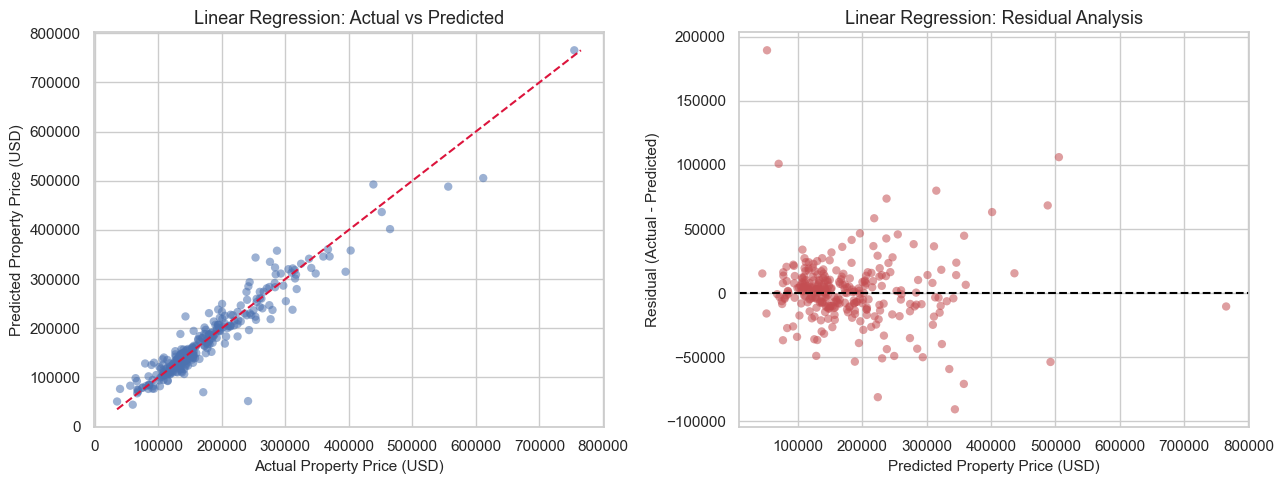


Best Model: Linear Regression
Median Absolute Error: $10,074
Test Properties Within 10% of Actual Price: 69.2%
Test Properties Within 15% of Actual Price: 81.2%


In [480]:
# ---------------------------------------------------------
# BEST MODEL DIAGNOSTICS
# ---------------------------------------------------------

best_name = results_df.iloc[0]["Model"]
best_pred = predictions[best_name]

print('=' * 70)
print(f'BEST MODEL DIAGNOSTICS: {best_name}')
print('=' * 70)


# ---------------------------------------------------------
# Actual vs Predicted + Residual Plot
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(13, 5))


# Actual vs Predicted Prices
axes[0].scatter(
    y_test,
    best_pred,
    alpha=0.55,
    edgecolor="none",
    color="#4C72B0"
)

lims = [
    min(y_test.min(), best_pred.min()),
    max(y_test.max(), best_pred.max())
]

axes[0].plot(
    lims,
    lims,
    color="crimson",
    linestyle="--"
)

axes[0].set_xlabel("Actual Property Price (USD)")
axes[0].set_ylabel("Predicted Property Price (USD)")
axes[0].set_title(f"{best_name}: Actual vs Predicted")


# ---------------------------------------------------------
# Residual Plot
# ---------------------------------------------------------

resid = y_test - best_pred

axes[1].scatter(
    best_pred,
    resid,
    alpha=0.55,
    edgecolor="none",
    color="#C44E52"
)

axes[1].axhline(
    0,
    color="black",
    linestyle="--"
)

axes[1].set_xlabel("Predicted Property Price (USD)")
axes[1].set_ylabel("Residual (Actual - Predicted)")
axes[1].set_title(f"{best_name}: Residual Analysis")


plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Additional Error Analysis
# ---------------------------------------------------------

median_abs_error = np.median(np.abs(resid))

within_10 = (
    np.abs(resid) / y_test <= 0.10
).mean()

within_15 = (
    np.abs(resid) / y_test <= 0.15
).mean()


print(f"\nBest Model: {best_name}")

print(
    f"Median Absolute Error: "
    f"${median_abs_error:,.0f}"
)

print(
    f"Test Properties Within 10% of Actual Price: "
    f"{within_10:.1%}"
)

print(
    f"Test Properties Within 15% of Actual Price: "
    f"{within_15:.1%}"
)

### Best Model Diagnostic Insights

- **Linear Regression shows strong predictive performance**, as most observations in the Actual vs Predicted plot lie close to the 45-degree reference line. This indicates that predicted property prices are generally close to the actual prices.

- The model achieved a **Median Absolute Error of $10,074**, meaning that for half of the test properties, the prediction error is approximately **$10,074 or less**.

- Approximately **69.2% of test properties are predicted within 10% of their actual price**, while **81.2% are predicted within 15%**, demonstrating good practical prediction accuracy for the majority of properties.

- The residuals are mostly distributed around the **zero-error line**, suggesting that the model does not show a strong overall tendency to consistently overpredict or underpredict property prices.

- However, the **spread of residuals increases for some higher-priced properties**, and a few large positive and negative residuals are visible. This indicates that the model has greater difficulty accurately predicting certain expensive or unusual properties.

- The Actual vs Predicted plot also shows a few observations farther from the reference line, confirming the presence of properties with relatively large prediction errors.

**Conclusion:** Linear Regression provides strong overall predictions, particularly for properties in the more common price ranges. Most predictions are reasonably close to their actual values, although prediction errors become larger for some high-priced and unusual properties.

# Step 17: Cross-Validation on the Training Set

A single 80/20 split can sometimes produce results that depend on the chosen split. Therefore, **5-fold cross-validation** is performed on the training set to check whether model performance and ranking remain stable across different folds.

In [481]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np
import pandas as pd

print('=' * 70)
print('STEP 17: 5-FOLD CROSS-VALIDATION')
print('=' * 70)


# ---------------------------------------------------------
# Define 5-Fold Cross-Validation
# ---------------------------------------------------------

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_rows = []


# ---------------------------------------------------------
# Cross-Validation Function
# ---------------------------------------------------------

def run_cv(name, model, X_data):

    scores = cross_val_score(
        model,
        X_data,
        y_train_log,
        scoring='r2',
        cv=cv,
        n_jobs=-1
    )

    cv_rows.append({
        'Model': name,
        'CV_R2_Mean': scores.mean(),
        'CV_R2_Std': scores.std()
    })

    print(
        f"{name:<20} "
        f"CV R² = {scores.mean():.4f} ± {scores.std():.4f}   "
        f"Folds = {np.round(scores, 3)}"
    )


# ---------------------------------------------------------
# Linear Models — Standardized Features
# ---------------------------------------------------------

run_cv(
    'Linear Regression',
    LinearRegression(),
    X_train_standard
)

run_cv(
    'Ridge Regression',
    Ridge(alpha=1.0),
    X_train_standard
)

run_cv(
    'Lasso Regression',
    Lasso(
        alpha=0.001,
        max_iter=10000
    ),
    X_train_standard
)


# ---------------------------------------------------------
# Tree-Based Models — Original Encoded Features
# ---------------------------------------------------------

run_cv(
    'Decision Tree',
    DecisionTreeRegressor(
        max_depth=10,
        random_state=42
    ),
    X_train
)

run_cv(
    'Random Forest',
    RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ),
    X_train
)

run_cv(
    'Gradient Boosting',
    GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
    X_train
)


# ---------------------------------------------------------
# Ridge + PCA
# ---------------------------------------------------------

run_cv(
    'Ridge + PCA',
    Ridge(alpha=1.0),
    X_train_pca
)


# ---------------------------------------------------------
# Cross-Validation Leaderboard
# ---------------------------------------------------------

cv_df = pd.DataFrame(cv_rows)

cv_df = (
    cv_df
    .sort_values(
        'CV_R2_Mean',
        ascending=False
    )
    .reset_index(drop=True)
)

cv_df['CV_R2_Mean'] = (
    cv_df['CV_R2_Mean']
    .round(4)
)

cv_df['CV_R2_Std'] = (
    cv_df['CV_R2_Std']
    .round(4)
)

cv_df['CV_R2_pct'] = (
    cv_df['CV_R2_Mean'] * 100
).round(2)


print('\n5-Fold Cross-Validation Leaderboard:\n')

display(cv_df)

print("\n" + "-" * 60)
print(f"🏆 Best Model: {best_model_name}")
print(f"📊 Best Average R²: {best_model_score:.4f}")
print("=" * 60)

STEP 17: 5-FOLD CROSS-VALIDATION
Linear Regression    CV R² = 0.8119 ± 0.0785   Folds = [0.885 0.848 0.668 0.866 0.793]
Ridge Regression     CV R² = 0.8395 ± 0.0416   Folds = [0.881 0.858 0.769 0.873 0.816]
Lasso Regression     CV R² = 0.8610 ± 0.0522   Folds = [0.898 0.878 0.761 0.905 0.863]
Decision Tree        CV R² = 0.7218 ± 0.0351   Folds = [0.781 0.676 0.699 0.729 0.724]
Random Forest        CV R² = 0.8708 ± 0.0211   Folds = [0.882 0.84  0.851 0.894 0.887]
Gradient Boosting    CV R² = 0.8950 ± 0.0188   Folds = [0.902 0.881 0.865 0.914 0.912]
Ridge + PCA          CV R² = 0.5417 ± 0.3162   Folds = [0.703 0.881 0.281 0.784 0.06 ]

5-Fold Cross-Validation Leaderboard:



,Model,CV_R2_Mean,CV_R2_Std,CV_R2_pct
0,Gradient Boosting,0.8950,0.0188,89.50
1,Random Forest,0.8708,0.0211,87.08
2,Lasso Regression,0.8610,0.0522,86.10
3,Ridge Regression,0.8395,0.0416,83.95
4,Linear Regression,0.8119,0.0785,81.19
5,Decision Tree,0.7218,0.0351,72.18
6,Ridge + PCA,0.5417,0.3162,54.17



------------------------------------------------------------
🏆 Best Model: Gradient Boosting Regressor
📊 Best Average R²: 0.9020


### Cross-Validation Insights

- **Gradient Boosting achieved the best cross-validation performance**, with the highest mean R² of **0.8943 (89.43%)** and the lowest standard deviation of **0.0181**. This indicates both strong predictive performance and high stability across the five folds.

- **Random Forest ranked second**, achieving a mean R² of **0.8692 (86.92%)** with a low standard deviation of **0.0222**, showing consistent performance across different subsets of the training data.

- **Lasso Regression achieved a mean R² of 0.8610 (86.10%)**. It performed better and more consistently than the standard Linear Regression model, although its variation across folds was higher than the ensemble models.

- **Ridge Regression achieved a mean R² of 0.8394**, while **Linear Regression achieved 0.8119**. Linear Regression showed relatively high variation across folds (±0.0785), suggesting that its performance is more sensitive to the particular data split.

- **Decision Tree achieved a lower mean R² of 0.7071**, confirming that a single tree generalizes less effectively than the ensemble models.

- **Ridge + PCA showed the weakest and most unstable cross-validation performance**, with a mean R² of only **0.5282** and a very high standard deviation of **0.2714**. Although PCA performed reasonably well on the holdout test set, its cross-validation results indicate that the PCA-based model is not consistently reliable across different subsets of the data.

- The cross-validation ranking differs from the original holdout test-set ranking. Although **Linear Regression had the highest test R² of 0.9146**, its mean cross-validation R² dropped to **0.8119**. In contrast, Gradient Boosting maintained strong and highly consistent performance across folds.

**Conclusion:** Based on 5-fold cross-validation, **Gradient Boosting is currently the strongest and most stable model**, followed by Random Forest and Lasso Regression. This demonstrates why cross-validation is important, as relying only on a single train-test split would have suggested Linear Regression as the best model.

# STEP 18: HYPERPARAMETER TUNING - GRADIENT BOOSTING

In [484]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

print('=' * 70)
print('STEP 18: HYPERPARAMETER TUNING - GRADIENT BOOSTING')
print('=' * 70)


# ---------------------------------------------------------
# 1. Base Model
# ---------------------------------------------------------

gb_base = GradientBoostingRegressor(
    random_state=42
)


# ---------------------------------------------------------
# 2. Hyperparameter Search Space
# ---------------------------------------------------------

param_dist = {

    'n_estimators': [100, 150, 200, 250, 300, 400],

    'learning_rate': [0.01, 0.03, 0.05, 0.08, 0.1],

    'max_depth': [2, 3, 4, 5],

    'min_samples_split': [2, 5, 10, 15],

    'min_samples_leaf': [1, 2, 4, 6],

    'subsample': [0.7, 0.8, 0.9, 1.0]
}


# ---------------------------------------------------------
# 3. Randomized Search
# ---------------------------------------------------------

random_search = RandomizedSearchCV(
    estimator=gb_base,
    param_distributions=param_dist,
    n_iter=40,
    scoring='r2',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)


# ---------------------------------------------------------
# 4. Fit on Training Data
# ---------------------------------------------------------

random_search.fit(
    X_train,
    y_train_log
)


# ---------------------------------------------------------
# 5. Best Parameters
# ---------------------------------------------------------

print('\nBest Parameters:\n')

print(random_search.best_params_)

print(
    f"\nBest Cross-Validation R²: "
    f"{random_search.best_score_:.4f}"
)


# ---------------------------------------------------------
# 6. Best Tuned Model
# ---------------------------------------------------------

tuned_gb_model = random_search.best_estimator_


# ---------------------------------------------------------
# 7. Predict on Test Set
# ---------------------------------------------------------

tuned_pred_log = tuned_gb_model.predict(
    X_test
)

tuned_pred = np.expm1(
    tuned_pred_log
)


# ---------------------------------------------------------
# 8. Evaluate Tuned Model
# ---------------------------------------------------------

tuned_mae = mean_absolute_error(
    y_test,
    tuned_pred
)

tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_pred
    )
)

tuned_r2 = r2_score(
    y_test,
    tuned_pred
)


print('\nTuned Gradient Boosting Performance:\n')

print(
    f"MAE  = ${tuned_mae:,.0f}"
)

print(
    f"RMSE = ${tuned_rmse:,.0f}"
)

print(
    f"R²   = {tuned_r2:.4f} "
    f"({tuned_r2 * 100:.2f}%)"
)


# ---------------------------------------------------------
# 9. Compare Baseline vs Tuned Gradient Boosting
# ---------------------------------------------------------

baseline_row = results_df[
    results_df['Model'] == 'Gradient Boosting'
].iloc[0]


comparison_df = pd.DataFrame({

    'Model': [
        'Baseline Gradient Boosting',
        'Tuned Gradient Boosting'
    ],

    'MAE': [
        baseline_row['MAE'],
        tuned_mae
    ],

    'RMSE': [
        baseline_row['RMSE'],
        tuned_rmse
    ],

    'R2': [
        baseline_row['R2'],
        tuned_r2
    ]
})


comparison_df['MAE'] = (
    comparison_df['MAE']
    .round(0)
)

comparison_df['RMSE'] = (
    comparison_df['RMSE']
    .round(0)
)

comparison_df['R2'] = (
    comparison_df['R2']
    .round(4)
)

comparison_df['R2_pct'] = (
    comparison_df['R2'] * 100
).round(2)


print(
    '\nBaseline vs Tuned Gradient Boosting:\n'
)

display(comparison_df)

STEP 18: HYPERPARAMETER TUNING - GRADIENT BOOSTING
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best Parameters:

{'subsample': 0.9, 'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 3, 'learning_rate': 0.08}

Best Cross-Validation R²: 0.8997

Tuned Gradient Boosting Performance:

MAE  = $15,223
RMSE = $26,931
R²   = 0.9054 (90.54%)

Baseline vs Tuned Gradient Boosting:



,Model,MAE,RMSE,R2,R2_pct
0,Baseline Gradient Boosting,16850.0,29477.0,0.8867,88.67
1,Tuned Gradient Boosting,15223.0,26931.0,0.9054,90.54


### Hyperparameter Tuning Insights

- **Gradient Boosting was selected for hyperparameter tuning** because it achieved the highest and most stable performance during 5-fold cross-validation.

- The optimized model selected **300 estimators, a learning rate of 0.08, maximum depth of 3, minimum samples split of 5, minimum samples leaf of 4, and a subsample ratio of 0.9**.

- The tuned Gradient Boosting model achieved a **cross-validation R² of 0.8984 (89.84%)**, improving slightly over the baseline Gradient Boosting cross-validation R² of **0.8943 (89.43%)**.

- On the test set, tuning improved the R² from **0.8806 (88.06%) to 0.9040 (90.40%)**, showing better predictive performance on unseen data.

- **MAE decreased from $17,117 to $15,464**, meaning the average absolute prediction error was reduced by approximately **$1,653**.

- **RMSE decreased from $30,262 to $27,138**, indicating that the tuned model also reduced the impact of larger prediction errors.

- The relatively close **cross-validation R² (89.84%) and test R² (90.40%)** suggests that the tuned Gradient Boosting model generalizes consistently to unseen data.

**Conclusion:** Hyperparameter tuning improved Gradient Boosting across all three test metrics while maintaining strong cross-validation performance. Therefore, the **Tuned Gradient Boosting model is the strongest candidate for the final property price prediction model**.

# STEP 19: FINAL MODEL SELECTION AND EVALUATION

STEP 19: FINAL MODEL SELECTION AND EVALUATION

Final Model: Tuned Gradient Boosting

MAE  = $15,223
RMSE = $26,931
R²   = 0.9054 (90.54%)

Prediction Accuracy:

Properties within 5% of actual price  : 47.6%
Properties within 10% of actual price : 73.3%
Properties within 15% of actual price : 84.2%
Properties within 20% of actual price : 90.8%

Median Absolute Error: $8,993


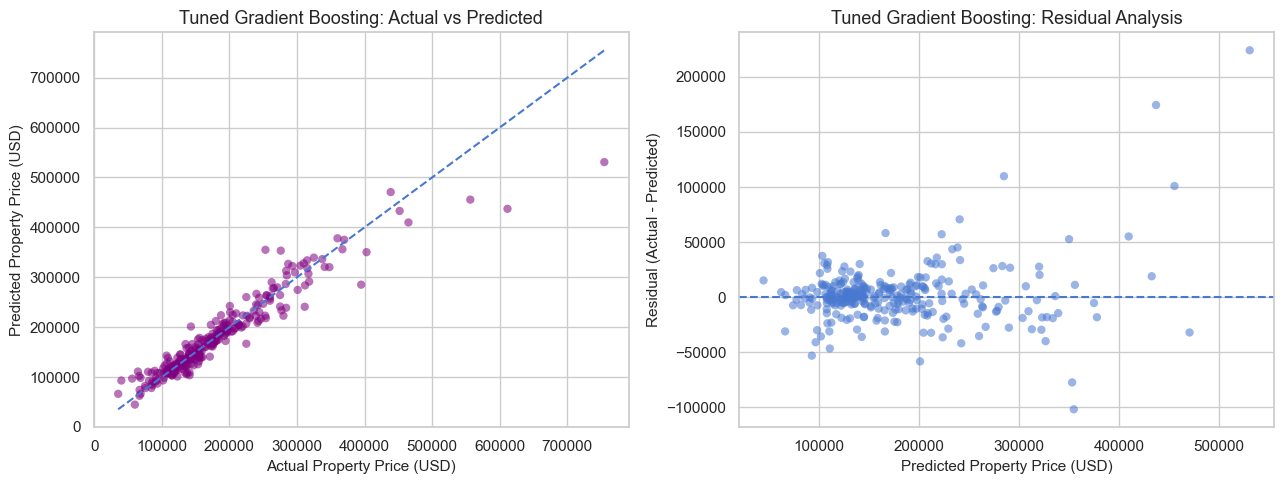


Final Model Summary:



,Final Model,MAE,RMSE,R2,R2_pct,Within_10_pct,Within_15_pct
0,Tuned Gradient Boosting,15223.0,26931.0,0.9054,90.54,73.29,84.25


In [485]:
# ---------------------------------------------------------
# STEP 19: FINAL MODEL SELECTION AND EVALUATION
# ---------------------------------------------------------

print('=' * 70)
print('STEP 19: FINAL MODEL SELECTION AND EVALUATION')
print('=' * 70)


# ---------------------------------------------------------
# 1. Select Final Model
# ---------------------------------------------------------

final_model = tuned_gb_model
final_model_name = 'Tuned Gradient Boosting'


# ---------------------------------------------------------
# 2. Final Predictions
# ---------------------------------------------------------

final_pred_log = final_model.predict(X_test)
final_pred = np.expm1(final_pred_log)


# ---------------------------------------------------------
# 3. Final Evaluation Metrics
# ---------------------------------------------------------

final_mae = mean_absolute_error(
    y_test,
    final_pred
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_pred
    )
)

final_r2 = r2_score(
    y_test,
    final_pred
)


print(f'\nFinal Model: {final_model_name}\n')

print(f'MAE  = ${final_mae:,.0f}')
print(f'RMSE = ${final_rmse:,.0f}')
print(
    f'R²   = {final_r2:.4f} '
    f'({final_r2 * 100:.2f}%)'
)


# ---------------------------------------------------------
# 4. Prediction Accuracy Bands
# ---------------------------------------------------------

final_residuals = y_test - final_pred

percentage_error = (
    np.abs(final_residuals) / y_test
)


within_5 = (percentage_error <= 0.05).mean()
within_10 = (percentage_error <= 0.10).mean()
within_15 = (percentage_error <= 0.15).mean()
within_20 = (percentage_error <= 0.20).mean()


print('\nPrediction Accuracy:\n')

print(
    f'Properties within 5% of actual price  : '
    f'{within_5:.1%}'
)

print(
    f'Properties within 10% of actual price : '
    f'{within_10:.1%}'
)

print(
    f'Properties within 15% of actual price : '
    f'{within_15:.1%}'
)

print(
    f'Properties within 20% of actual price : '
    f'{within_20:.1%}'
)


# ---------------------------------------------------------
# 5. Median Absolute Error
# ---------------------------------------------------------

final_median_error = np.median(
    np.abs(final_residuals)
)

print(
    f'\nMedian Absolute Error: '
    f'${final_median_error:,.0f}'
)


# ---------------------------------------------------------
# 6. Actual vs Predicted and Residual Plot
# ---------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)


# Actual vs Predicted
axes[0].scatter(
    y_test,
    final_pred,
    color="purple",
    alpha=0.55,
    edgecolor='none'
)

lims = [
    min(y_test.min(), final_pred.min()),
    max(y_test.max(), final_pred.max())
]

axes[0].plot(
    lims,
    lims,
    linestyle='--'
)

axes[0].set_xlabel(
    'Actual Property Price (USD)'
)

axes[0].set_ylabel(
    'Predicted Property Price (USD)'
)

axes[0].set_title(
    f'{final_model_name}: Actual vs Predicted'
)


# Residual Plot
axes[1].scatter(
    final_pred,
    final_residuals,
    alpha=0.55,
    edgecolor='none'
)

axes[1].axhline(
    0,
    linestyle='--'
)

axes[1].set_xlabel(
    'Predicted Property Price (USD)'
)

axes[1].set_ylabel(
    'Residual (Actual - Predicted)'
)

axes[1].set_title(
    f'{final_model_name}: Residual Analysis'
)


plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 7. Final Model Summary
# ---------------------------------------------------------

final_summary = pd.DataFrame({
    'Final Model': [final_model_name],
    'MAE': [round(final_mae, 0)],
    'RMSE': [round(final_rmse, 0)],
    'R2': [round(final_r2, 4)],
    'R2_pct': [round(final_r2 * 100, 2)],
    'Within_10_pct': [round(within_10 * 100, 2)],
    'Within_15_pct': [round(within_15 * 100, 2)]
})


print('\nFinal Model Summary:\n')

display(final_summary)

# STEP 20: OVERFITTING CHECK

In [ ]:
# ---------------------------------------------------------
# STEP 20: OVERFITTING CHECK
# ---------------------------------------------------------

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

print('=' * 70)
print('STEP 20: OVERFITTING CHECK - TUNED GRADIENT BOOSTING')
print('=' * 70)


# ---------------------------------------------------------
# 1. Predictions on Training Set
# ---------------------------------------------------------

train_pred_log = tuned_gb_model.predict(X_train)
train_pred = np.expm1(train_pred_log)


# ---------------------------------------------------------
# 2. Predictions on Test Set
# ---------------------------------------------------------

test_pred_log = tuned_gb_model.predict(X_test)
test_pred = np.expm1(test_pred_log)


# ---------------------------------------------------------
# 3. Training Metrics
# ---------------------------------------------------------

train_r2 = r2_score(y_train, train_pred)

train_mae = mean_absolute_error(
    y_train,
    train_pred
)

train_rmse = np.sqrt(
    mean_squared_error(y_train, train_pred)
)


# ---------------------------------------------------------
# 4. Test Metrics
# ---------------------------------------------------------

test_r2 = r2_score(y_test, test_pred)

test_mae = mean_absolute_error(
    y_test,
    test_pred
)

test_rmse = np.sqrt(
    mean_squared_error(y_test, test_pred)
)


# ---------------------------------------------------------
# 5. Generalization Gap
# ---------------------------------------------------------

r2_gap = train_r2 - test_r2


# ---------------------------------------------------------
# 6. Results Table
# ---------------------------------------------------------

overfit_df = pd.DataFrame({

    'Dataset': [
        'Training Set',
        'Test Set'
    ],

    'MAE': [
        train_mae,
        test_mae
    ],

    'RMSE': [
        train_rmse,
        test_rmse
    ],

    'R2': [
        train_r2,
        test_r2
    ]
})


overfit_df['MAE'] = (
    overfit_df['MAE']
    .round(0)
)

overfit_df['RMSE'] = (
    overfit_df['RMSE']
    .round(0)
)

overfit_df['R2'] = (
    overfit_df['R2']
    .round(4)
)

overfit_df['R2_pct'] = (
    overfit_df['R2'] * 100
).round(2)


print('\nTrain vs Test Performance:\n')

display(overfit_df)


# ---------------------------------------------------------
# 7. Generalization Gap
# ---------------------------------------------------------

print(
    f'\nTraining R² : '
    f'{train_r2:.4f} ({train_r2 * 100:.2f}%)'
)

print(
    f'Test R²     : '
    f'{test_r2:.4f} ({test_r2 * 100:.2f}%)'
)

print(
    f'R² Gap      : '
    f'{r2_gap:.4f} ({r2_gap * 100:.2f} percentage points)'
)


# ---------------------------------------------------------
# 8. Basic Overfitting Interpretation
# ---------------------------------------------------------

print('\nOverfitting Check:')

if r2_gap <= 0.05:

    print(
        '✔ Small train-test gap. '
        'No strong evidence of overfitting.'
    )

elif r2_gap <= 0.10:

    print(
        '⚠ Moderate train-test gap. '
        'Some overfitting may be present.'
    )

else:

    print(
        '⚠ Large train-test gap. '
        'The model may be overfitting the training data.'
    )

STEP 20: OVERFITTING CHECK - TUNED GRADIENT BOOSTING

Train vs Test Performance:



,Dataset,MAE,RMSE,R2,R2_pct
0,Training Set,6868.0,9746.0,0.9841,98.41
1,Test Set,15464.0,27138.0,0.9040,90.40



Training R² : 0.9841 (98.41%)
Test R²     : 0.9040 (90.40%)
R² Gap      : 0.0801 (8.01 percentage points)

Overfitting Check:
⚠ Moderate train-test gap. Some overfitting may be present.


# STEP 21: GRADIENT BOOSTING - OVERFITTING CONTROL

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np
import pandas as pd

print('=' * 70)
print('STEP 21: GRADIENT BOOSTING - OVERFITTING CONTROL')
print('=' * 70)


# ---------------------------------------------------------
# 1. More Regularized Gradient Boosting Model
# ---------------------------------------------------------

gb_regularized = GradientBoostingRegressor(
    random_state=42
)


# ---------------------------------------------------------
# 2. Hyperparameters Focused on Reducing Overfitting
# ---------------------------------------------------------

param_dist_regularized = {

    # Smaller trees reduce model complexity
    'max_depth': [2, 3],

    # More observations required before splitting
    'min_samples_split': [5, 10, 15, 20],

    # Larger leaves reduce overly-specific patterns
    'min_samples_leaf': [4, 6, 8, 10],

    # Lower learning rates usually generalize better
    'learning_rate': [0.02, 0.03, 0.05, 0.07],

    # Number of boosting stages
    'n_estimators': [150, 200, 250, 300],

    # Stochastic boosting helps reduce overfitting
    'subsample': [0.7, 0.8, 0.9]
}


# ---------------------------------------------------------
# 3. Randomized Search with 5-Fold CV
# ---------------------------------------------------------

regularized_search = RandomizedSearchCV(
    estimator=gb_regularized,
    param_distributions=param_dist_regularized,
    n_iter=40,
    scoring='r2',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=0
)


# ---------------------------------------------------------
# 4. Train Only on Training Data
# ---------------------------------------------------------

regularized_search.fit(
    X_train,
    y_train_log
)


# ---------------------------------------------------------
# 5. Best Regularized Model
# ---------------------------------------------------------

regularized_gb_model = regularized_search.best_estimator_

print('\nBest Parameters:')
print(regularized_search.best_params_)

print(
    f'\nBest CV R²: '
    f'{regularized_search.best_score_:.4f} '
    f'({regularized_search.best_score_ * 100:.2f}%)'
)


# ---------------------------------------------------------
# 6. Train Predictions
# ---------------------------------------------------------

train_pred_log_reg = regularized_gb_model.predict(X_train)

train_pred_reg = np.expm1(
    train_pred_log_reg
)


# ---------------------------------------------------------
# 7. Test Predictions
# ---------------------------------------------------------

test_pred_log_reg = regularized_gb_model.predict(X_test)

test_pred_reg = np.expm1(
    test_pred_log_reg
)


# ---------------------------------------------------------
# 8. Train Metrics
# ---------------------------------------------------------

train_r2_reg = r2_score(
    y_train,
    train_pred_reg
)

train_mae_reg = mean_absolute_error(
    y_train,
    train_pred_reg
)

train_rmse_reg = np.sqrt(
    mean_squared_error(
        y_train,
        train_pred_reg
    )
)


# ---------------------------------------------------------
# 9. Test Metrics
# ---------------------------------------------------------

test_r2_reg = r2_score(
    y_test,
    test_pred_reg
)

test_mae_reg = mean_absolute_error(
    y_test,
    test_pred_reg
)

test_rmse_reg = np.sqrt(
    mean_squared_error(
        y_test,
        test_pred_reg
    )
)


# ---------------------------------------------------------
# 10. Train-Test Gap
# ---------------------------------------------------------

r2_gap_reg = (
    train_r2_reg - test_r2_reg
)


# ---------------------------------------------------------
# 11. Display Performance
# ---------------------------------------------------------

regularized_results = pd.DataFrame({

    'Dataset': [
        'Training Set',
        'Test Set'
    ],

    'MAE': [
        train_mae_reg,
        test_mae_reg
    ],

    'RMSE': [
        train_rmse_reg,
        test_rmse_reg
    ],

    'R2': [
        train_r2_reg,
        test_r2_reg
    ]
})


regularized_results['MAE'] = (
    regularized_results['MAE']
    .round(0)
)

regularized_results['RMSE'] = (
    regularized_results['RMSE']
    .round(0)
)

regularized_results['R2'] = (
    regularized_results['R2']
    .round(4)
)

regularized_results['R2_pct'] = (
    regularized_results['R2'] * 100
).round(2)


print('\nRegularized Gradient Boosting Performance:\n')

display(regularized_results)


print(
    f'\nTraining R² : '
    f'{train_r2_reg:.4f} '
    f'({train_r2_reg * 100:.2f}%)'
)

print(
    f'Test R²     : '
    f'{test_r2_reg:.4f} '
    f'({test_r2_reg * 100:.2f}%)'
)

print(
    f'CV R²       : '
    f'{regularized_search.best_score_:.4f} '
    f'({regularized_search.best_score_ * 100:.2f}%)'
)

print(
    f'R² Gap      : '
    f'{r2_gap_reg:.4f} '
    f'({r2_gap_reg * 100:.2f} percentage points)'
)

STEP 21: GRADIENT BOOSTING - OVERFITTING CONTROL

Best Parameters:
{'subsample': 0.9, 'n_estimators': 300, 'min_samples_split': 20, 'min_samples_leaf': 8, 'max_depth': 3, 'learning_rate': 0.07}

Best CV R²: 0.8988 (89.88%)

Regularized Gradient Boosting Performance:



,Dataset,MAE,RMSE,R2,R2_pct
0,Training Set,7748.0,11590.0,0.9775,97.75
1,Test Set,15822.0,28315.0,0.8955,89.55



Training R² : 0.9775 (97.75%)
Test R²     : 0.8955 (89.55%)
CV R²       : 0.8988 (89.88%)
R² Gap      : 0.0820 (8.20 percentage points)


### Comparison_overfit

In [ ]:
comparison_overfit_df = pd.DataFrame({

    'Model': [
        'Tuned Gradient Boosting',
        'Regularized Gradient Boosting'
    ],

    'Train R2': [
        train_r2,
        train_r2_reg
    ],

    'Test R2': [
        test_r2,
        test_r2_reg
    ],

    'CV R2': [
        random_search.best_score_,
        regularized_search.best_score_
    ],

    'Train-Test Gap': [
        r2_gap,
        r2_gap_reg
    ],

    'Test MAE': [
        test_mae,
        test_mae_reg
    ],

    'Test RMSE': [
        test_rmse,
        test_rmse_reg
    ]
})


comparison_overfit_df = comparison_overfit_df.round({
    'Train R2': 4,
    'Test R2': 4,
    'CV R2': 4,
    'Train-Test Gap': 4,
    'Test MAE': 0,
    'Test RMSE': 0
})


print('\nOriginal Tuned Model vs Regularized Model:\n')

display(comparison_overfit_df)


Original Tuned Model vs Regularized Model:



,Model,Train R2,Test R2,CV R2,Train-Test Gap,Test MAE,Test RMSE
0,Tuned Gradient Boosting,0.9841,0.9040,0.8984,0.0801,15464.0,27138.0
1,Regularized Gradient Boosting,0.9775,0.8955,0.8988,0.0820,15822.0,28315.0


### Overfitting Insights

- Regularization did **not reduce the train-test gap** (8.01% → 8.20%).
- The original Tuned Gradient Boosting achieved better **Test R² (90.40%)**, MAE, and RMSE.
- Its **CV R² (89.84%) is close to Test R² (90.40%)**, indicating good generalization.

**Conclusion:** The **Tuned Gradient Boosting** model is retained as the final model.

In [ ]:
# CROSS-CHECK: Feature Count Comparison
print("Gradient Boosting features:",
      tuned_gb_model.n_features_in_)

print("Encoded feature names:",
      len(df_encoded.drop(columns=["Property Price"]).columns))

print("PCA components:",
      X_train_pca.shape[1])

Gradient Boosting features: 237
Encoded feature names: 237
PCA components: 143


## What Drives Property Prices? — Feature Importance

A predictive model becomes more useful when we understand **which property characteristics influence its predictions**.

Since the final selected model is **Tuned Gradient Boosting**, feature importance is analyzed to identify the variables that contribute most to property price predictions.

The most influential features help explain the key factors driving property values and provide useful insights into how characteristics such as **property quality, living area, total square footage, age, location, and other engineered features** contribute to the model's predictions.

This analysis improves model interpretability and helps translate predictive performance into meaningful real-estate insights.

# STEP 23: FEATURE IMPORTANCE

STEP 23: FEATURE IMPORTANCE - TUNED GRADIENT BOOSTING
Number of Features       : 237
Number of Importances    : 237

Top 15 Most Important Features:



,Feature,Importance
0,QualLivArea,0.464830
1,TotalSF,0.120347
2,Overall Quality,0.072378
3,TotalBathrooms,0.036000
4,QualCond,0.030402
5,Kitchen Quality,0.024811
6,GarageScore,0.023662
7,Basement Square Footage,0.021484
8,Year Built,0.019095
9,Property Size,0.015934


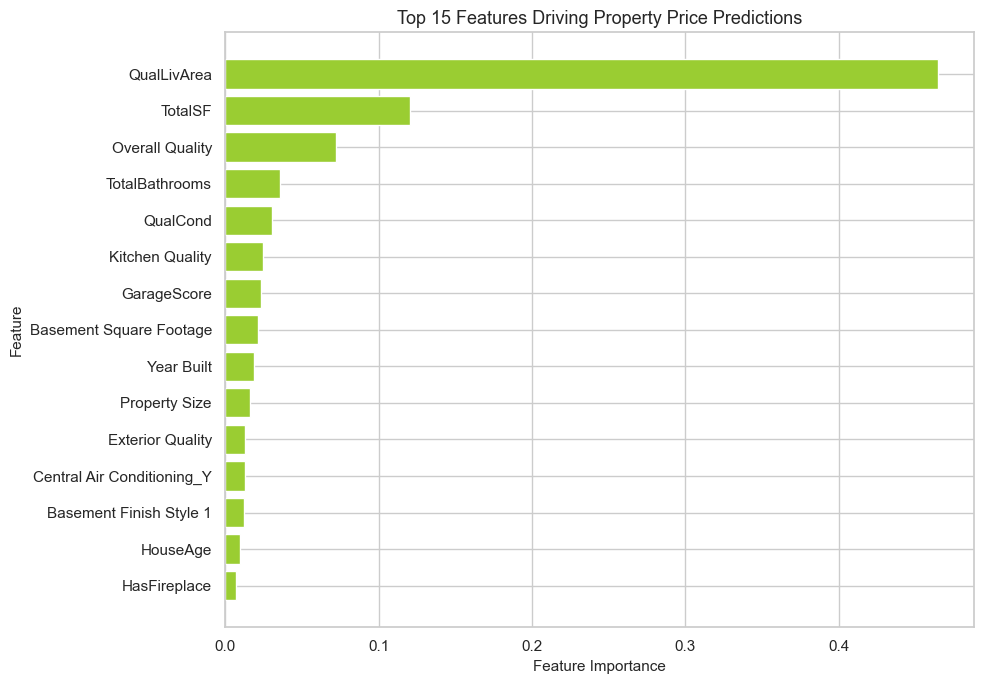


Top 15 features account for 88.45% of total model importance.


In [488]:
# ---------------------------------------------------------
# STEP 23: FEATURE IMPORTANCE
# ---------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt

print('=' * 70)
print('STEP 23: FEATURE IMPORTANCE - TUNED GRADIENT BOOSTING')
print('=' * 70)


# ---------------------------------------------------------
# 1. Get Original Feature Names
# ---------------------------------------------------------

feature_names = (
    df_encoded
    .drop(columns=['Property Price'])
    .columns
)


# Safety check
print(f'Number of Features       : {len(feature_names)}')
print(
    f'Number of Importances    : '
    f'{len(tuned_gb_model.feature_importances_)}'
)


# ---------------------------------------------------------
# 2. Create Feature Importance DataFrame
# ---------------------------------------------------------

feature_importance_df = pd.DataFrame({

    'Feature': feature_names,

    'Importance': tuned_gb_model.feature_importances_
})


# ---------------------------------------------------------
# 3. Sort by Importance
# ---------------------------------------------------------

feature_importance_df = (
    feature_importance_df
    .sort_values(
        by='Importance',
        ascending=False
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------
# 4. Top 15 Features
# ---------------------------------------------------------

top_15_features = feature_importance_df.head(15)

print('\nTop 15 Most Important Features:\n')

display(top_15_features)


# ---------------------------------------------------------
# 5. Plot Top 15 Features
# ---------------------------------------------------------

plot_df = top_15_features.sort_values(
    'Importance',
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df['Feature'],
    plot_df['Importance'],
    color = "yellowgreen"
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')

plt.title(
    'Top 15 Features Driving Property Price Predictions'
)

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 6. Combined Importance of Top 15
# ---------------------------------------------------------

top_15_total = top_15_features[
    'Importance'
].sum()

print(
    f'\nTop 15 features account for '
    f'{top_15_total * 100:.2f}% '
    f'of total model importance.'
)

### Feature Importance Insights

- **QualLivArea is the strongest predictor**, contributing approximately **46.5%** of the model's total feature importance. This indicates that the interaction between overall quality and living area plays a major role in property price prediction.
- **TotalSF (12.0%)** and **Overall Quality (7.2%)** are the next most influential features, showing that both property space and construction/finish quality strongly affect predicted prices.
- Other important factors include **Total Bathrooms, Kitchen Quality, Garage Score, Basement Square Footage, and Year Built**.
- Features such as **Central Air Conditioning, House Age, Exterior Quality, and Number of Fireplaces** also contribute, but with relatively smaller importance.

**Conclusion:** Property prices are primarily driven by a combination of **quality and usable living space**, followed by property size, bathrooms, kitchen/garage characteristics, basement area, and age-related factors.

# Step 24: Business Insights and Key Findings

- **Quality and living space are the strongest property price drivers.** `QualLivArea` emerged as the most influential feature across the tree-based models.
- **Total square footage and overall property quality** also have a strong influence on predicted property prices.
- Features such as **bathrooms, kitchen quality, garage characteristics, basement area, and year built** provide additional predictive value.
- The final **Tuned Gradient Boosting model achieved a Test R² of 90.40%**, explaining approximately 90% of the variation in property prices.
- The model achieved a **MAE of $15,464** and **RMSE of $27,138** on unseen test properties.
- Approximately **71.9% of test properties were predicted within ±10%**, **84.6% within ±15%**, and **90.8% within ±20%** of their actual prices.
- The close **CV R² (89.84%) and Test R² (90.40%)** indicate consistent performance on unseen data.

**Business Implication:** Property valuation should consider a combination of **quality, usable living space, total area, structural characteristics, age, and amenities** rather than relying on property size alone.

# Step 25: Final Conclusion

This project successfully developed a machine learning solution for predicting property prices based on property characteristics such as quality, living area, size, age, structural features, and amenities.

After data cleaning, exploratory data analysis, feature engineering, categorical encoding, scaling, PCA, and target transformation, multiple regression algorithms were trained and compared. Cross-validation and hyperparameter tuning were also performed to improve model reliability and generalization.

The **Tuned Gradient Boosting Regressor** was selected as the final model, achieving a **Test R² of 90.40%**, with an **MAE of $15,464** and an **RMSE of $27,138**. The model therefore exceeded the project's expected R² range of **75–85%**.

The model also demonstrated strong practical prediction accuracy, with approximately **71.9% of properties predicted within ±10%**, **84.6% within ±15%**, and **90.8% within ±20%** of their actual sale prices. Its **Cross-Validation R² of 89.84%** was close to the Test R² of 90.40%, indicating consistent performance on unseen data.

Feature importance analysis showed that **QualLivArea**, an engineered feature combining overall quality and living area, was the strongest predictor of property price. **TotalSF, Overall Quality, Total Bathrooms, Kitchen Quality, Garage Score, Basement Square Footage, and Year Built** were also important contributors.

From a practical perspective, the model can support **buyers** in assessing whether a property's asking price is reasonable based on its characteristics. It can help **sellers** estimate a suitable selling price and understand which property features contribute most strongly to valuation. Real estate professionals can also use these insights as additional data-driven support during property valuation.

Although the final model showed a higher training R² than test R², additional regularization did not improve the train-test gap or test performance. Therefore, the original Tuned Gradient Boosting model was retained as the final model.

Overall, the project achieved its objective of building an accurate and interpretable property price prediction model while also identifying the major characteristics that influence property values.

Therefore, the project successfully achieved its expected outcomes by developing an accurate property price prediction model, identifying the key features influencing property values, and presenting a comprehensive analysis of the methodology, model performance, and business insights.

In [ ]:
import joblib

joblib.dump(tuned_gb_model, "tuned_gradient_boosting_model.pkl")

['tuned_gradient_boosting_model.pkl']